In [5]:
import numpy as np
import pandas as pd
import os
import re
import pickle

from scipy import sparse
from scipy.cluster.hierarchy import dendrogram, linkage

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
from sklearn.decomposition import PCA, TruncatedSVD

from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering, BisectingKMeans
from sklearn.mixture import GaussianMixture
import hdbscan

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# 1. Ucitavamo podatke dobijene pretprocesiranjem

In [3]:
data_dir = "preprocessed_data"

labels = np.load(os.path.join(data_dir, "labels.npy"))

X_tfidf_reduced_stripped = sparse.load_npz(os.path.join(data_dir, "X_tfidf_reduced_stripped.npz"))
X_tfidf_reduced_prefixed = sparse.load_npz(os.path.join(data_dir, "X_tfidf_reduced_prefixed.npz"))
X_tfidf_full_stripped = sparse.load_npz(os.path.join(data_dir, "X_tfidf_full_stripped.npz"))
X_tfidf_full_prefixed = sparse.load_npz(os.path.join(data_dir, "X_tfidf_full_prefixed.npz"))

X_lsa_reduced_stripped = np.load(os.path.join(data_dir, "X_lsa_reduced_stripped.npy"))
X_lsa_reduced_prefixed = np.load(os.path.join(data_dir, "X_lsa_reduced_prefixed.npy"))
X_lsa_full_stripped = np.load(os.path.join(data_dir, "X_lsa_full_stripped.npy"))
X_lsa_full_prefixed = np.load(os.path.join(data_dir, "X_lsa_full_prefixed.npy"))

with open(os.path.join(data_dir, "feature_names_tfidf.pkl"), "rb") as f:
    feature_names_tfidf = pickle.load(f)
feature_names_reduced_stripped = feature_names_tfidf["feature_names_tfidf_reduced_stripped"]
feature_names_reduced_prefixed = feature_names_tfidf["feature_names_tfidf_reduced_prefixed"]
feature_names_full_stripped = feature_names_tfidf["feature_names_tfidf_full_stripped"]
feature_names_full_prefixed = feature_names_tfidf["feature_names_tfidf_full_prefixed"]

datasets = {
    "Reduced Stripped": X_lsa_reduced_stripped,
    "Reduced Prefixed": X_lsa_reduced_prefixed,
    "Full Stripped":    X_lsa_full_stripped,
    "Full Prefixed":    X_lsa_full_prefixed,
}

datasets_stripped = {
    "Reduced Stripped": X_lsa_reduced_stripped,
    "Full Stripped":    X_lsa_full_stripped,
}

clustering_results = []

# 2. Pomocna funkcija

In [3]:
print("Shape of labels:", labels.shape)
print("First 10 labels:", labels[:10])
print("Number of accepted (1):", np.sum(labels == 1))
print("Number of rejected (0):", np.sum(labels == 0))

Shape of labels: (3265,)
First 10 labels: [1 0 0 0 0 1 0 0 0 1]
Number of accepted (1): 1809
Number of rejected (0): 1456


In [4]:
labels[:10]

array([1, 0, 0, 0, 0, 1, 0, 0, 0, 1])

In [15]:
def show_cluster_composition(cluster_labels, X_tfidf, feature_names, k):

    results_df = pd.DataFrame({
    'cluster': cluster_labels,
    'true_label': ['accepted' if l == True else 'rejected' for l in labels ]
    })
    composition = (results_df
               .groupby(['cluster', 'true_label'])
               .size()
               .unstack(fill_value=0))
    composition['total']      = composition.sum(axis=1)
    composition['pct_accepted'] = (composition.get('accepted', 0) / composition['total'] * 100).round(1)
    composition.sort_values('total',ascending=False, inplace=False)[['accepted', 'rejected']].plot(
        kind='bar', stacked=True, figsize=(max((k/3), 8), max((k/6), 4)), color=['green','red'])
    plt.title('Accepted vs Rejected per Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Count')
    plt.legend(title='Label')
    plt.tight_layout()
    plt.show()
   
    top_term_list = [None] * k
    for i in range(k):
        mask = cluster_labels == i
        if mask.sum() == 0:
            top_term_list[i] = ''
            continue
        centroid_tfidf = X_tfidf[mask].mean(axis=0).A.flatten()
        top_idx = centroid_tfidf.argsort()[-10:][::-1]
        top_term_list[i] = ', '.join([feature_names[idx] for idx in top_idx])
        composition['top_terms'] = top_term_list
    composition = composition.sort_values('pct_accepted', ascending=False)
    
    return (composition.style
            .background_gradient(subset=['accepted'], cmap='Greens', vmax=160)
            .background_gradient(subset=['rejected'], cmap='Reds', vmax=160)
            .background_gradient(subset=['total'], cmap='Blues', vmax=400)
            .background_gradient(subset=['pct_accepted'], cmap='Purples')
            .set_properties(**{'text-align': 'left'})
           )

## Algoritam 1: K sredina
### Odredjujemo k

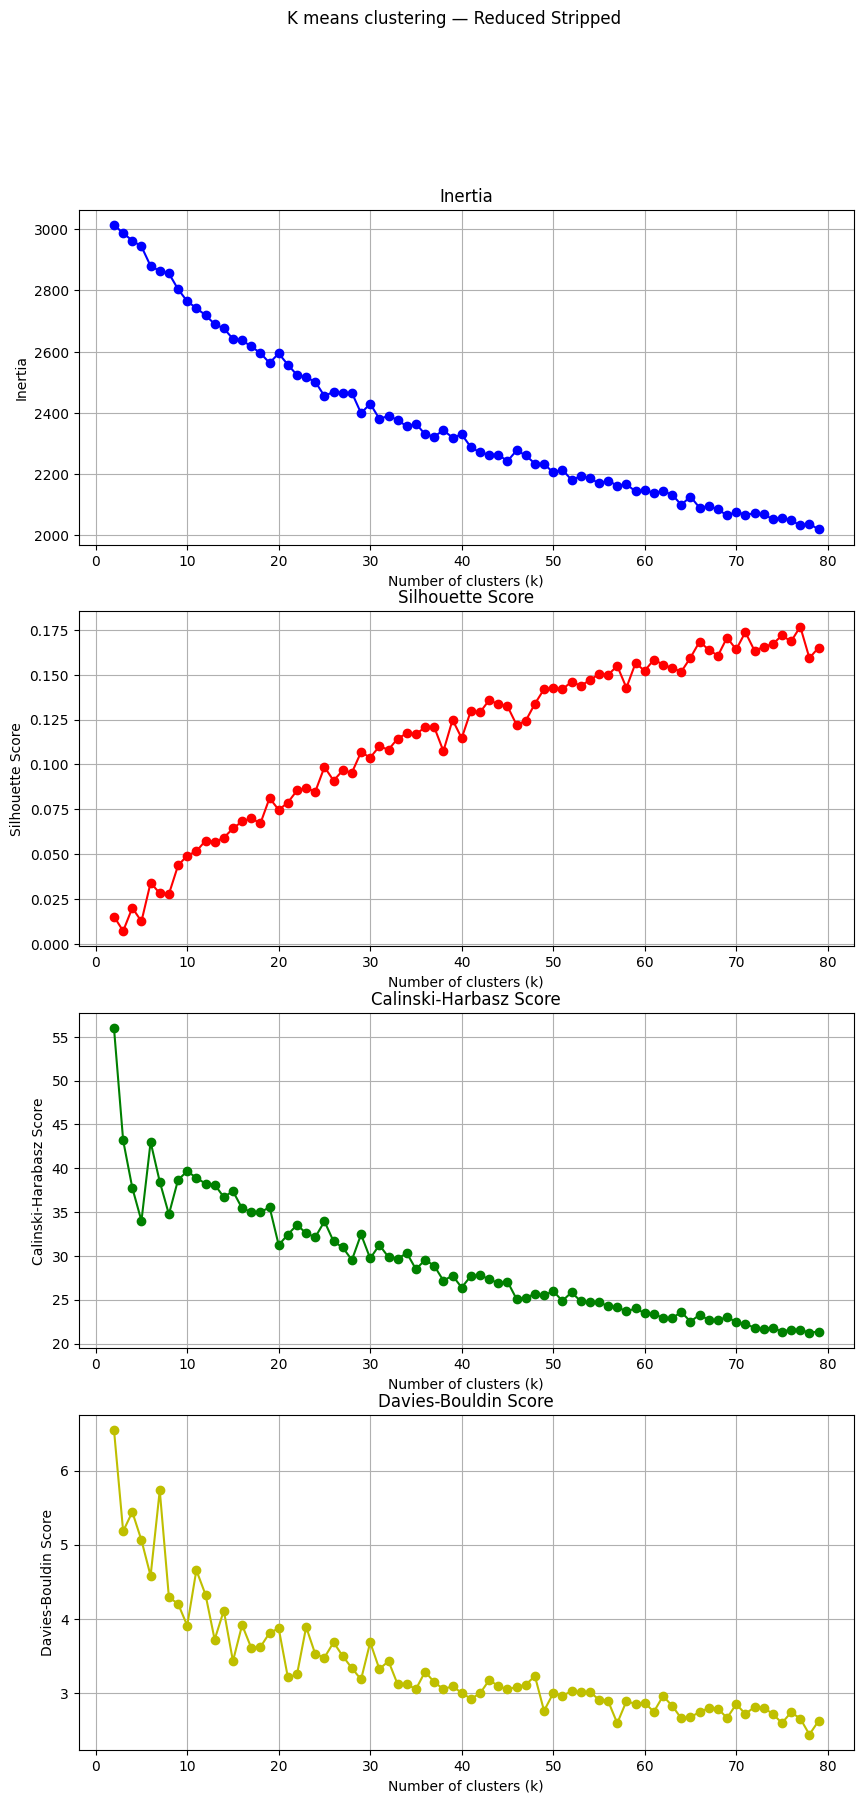

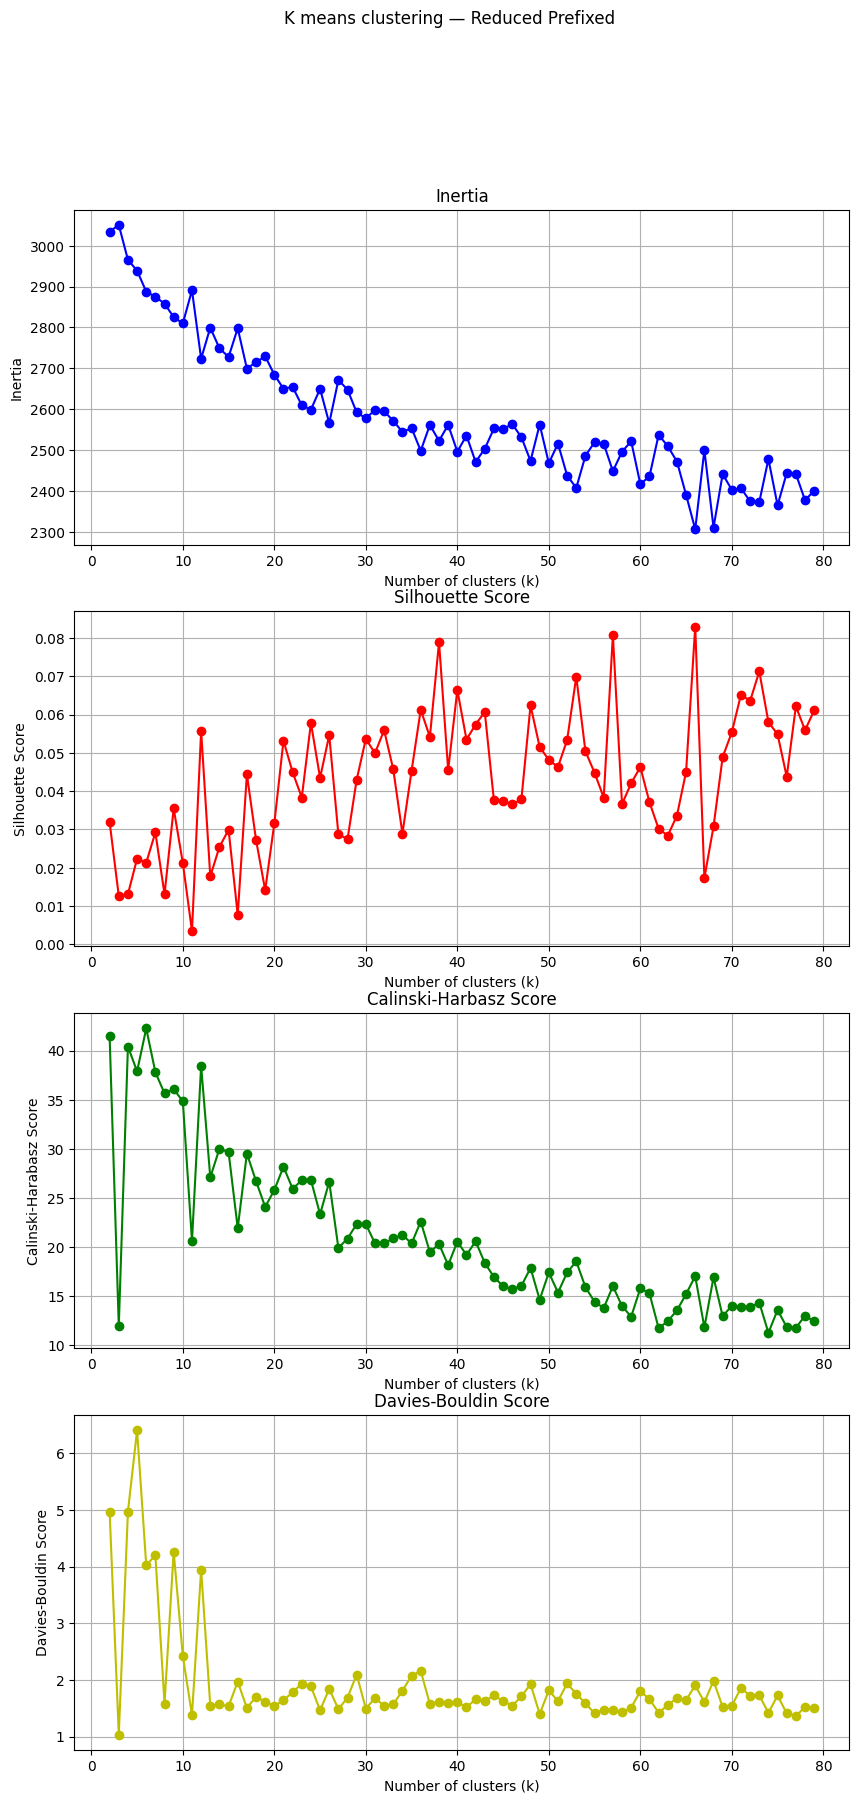

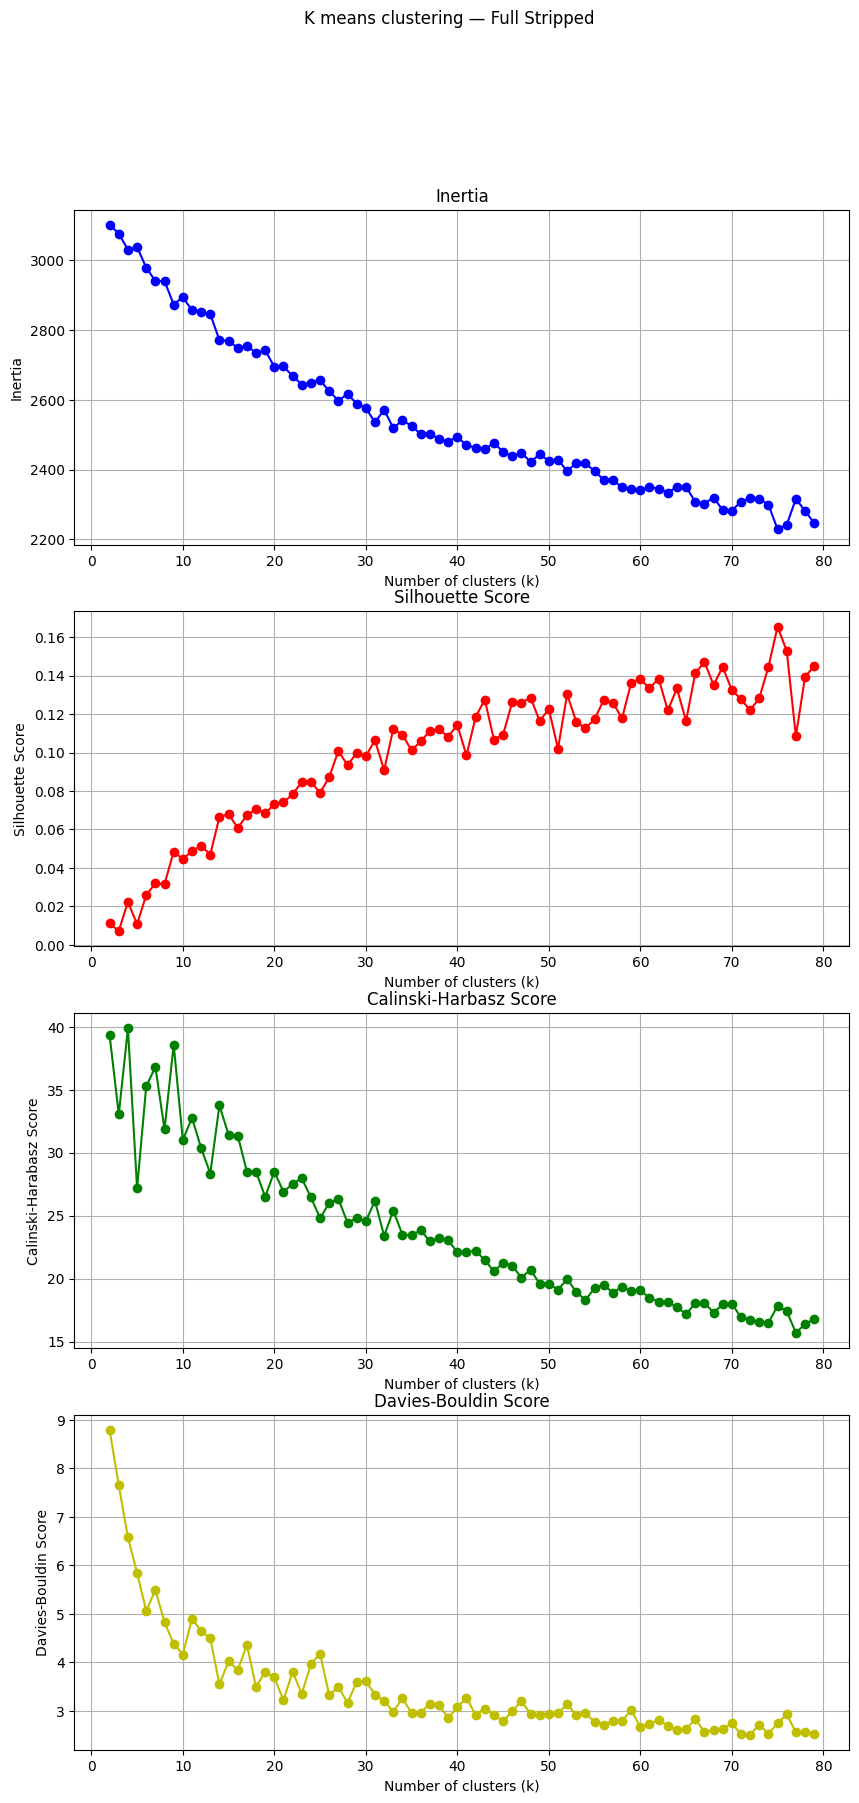

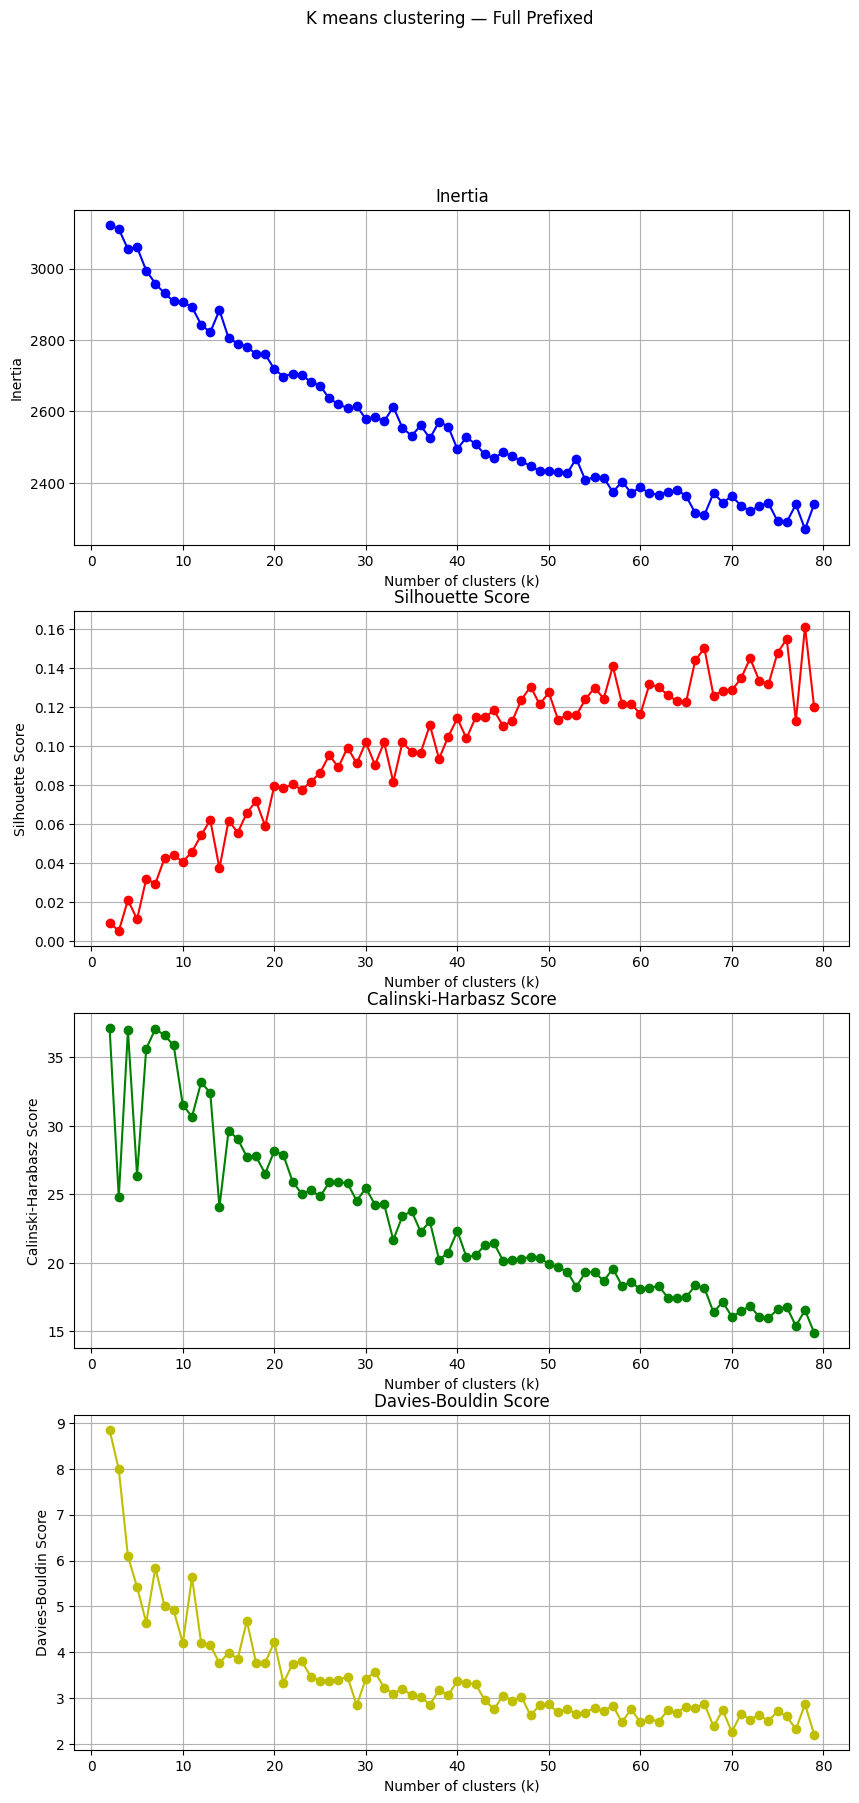

In [6]:
kmeans = {} 
k_range_km = range(2, 80)

for name, X_data in datasets.items():
    metrics = {"silhouette": [], "inertia": [], "calinski": [], "davies": []}
    for k in k_range_km:
        km = MiniBatchKMeans(n_clusters=k, random_state=8, n_init=50)
        preds = km.fit_predict(X_data)
        metrics["inertia"].append(km.inertia_)
        metrics["silhouette"].append(
            silhouette_score(X_data, preds, sample_size=1000, random_state=8)
        )
        metrics["calinski"].append(
            calinski_harabasz_score(X_data, preds)
        )
        metrics["davies"].append(
            davies_bouldin_score(X_data, preds)
        )
    kmeans[name] = metrics
    fig, axes = plt.subplots(4, 1, figsize=(10, 20))
    
    axes[0].plot(k_range_km, metrics["inertia"], 'bo-')
    axes[0].set_title('Inertia')
    axes[0].set_xlabel('Number of clusters (k)')
    axes[0].set_ylabel('Inertia')
    axes[0].grid(True)
    
    axes[1].plot(k_range_km, metrics["silhouette"], 'ro-')
    axes[1].set_title('Silhouette Score')
    axes[1].set_xlabel('Number of clusters (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].grid(True)
    
    axes[2].plot(k_range_km, metrics["calinski"], 'go-')
    axes[2].set_title('Calinski-Harbasz Score')
    axes[2].set_xlabel('Number of clusters (k)')
    axes[2].set_ylabel('Calinski-Harabasz Score')
    axes[2].grid(True)

    axes[3].plot(k_range_km, metrics["davies"], 'yo-')
    axes[3].set_title('Davies-Bouldin Score')
    axes[3].set_xlabel('Number of clusters (k)')
    axes[3].set_ylabel('Davies-Bouldin Score')
    axes[3].grid(True)

    plt.suptitle(f'K means clustering — {name}')
    plt.show()

### Poredimo rezultate dobijene nad razlicitim skupovima podataka

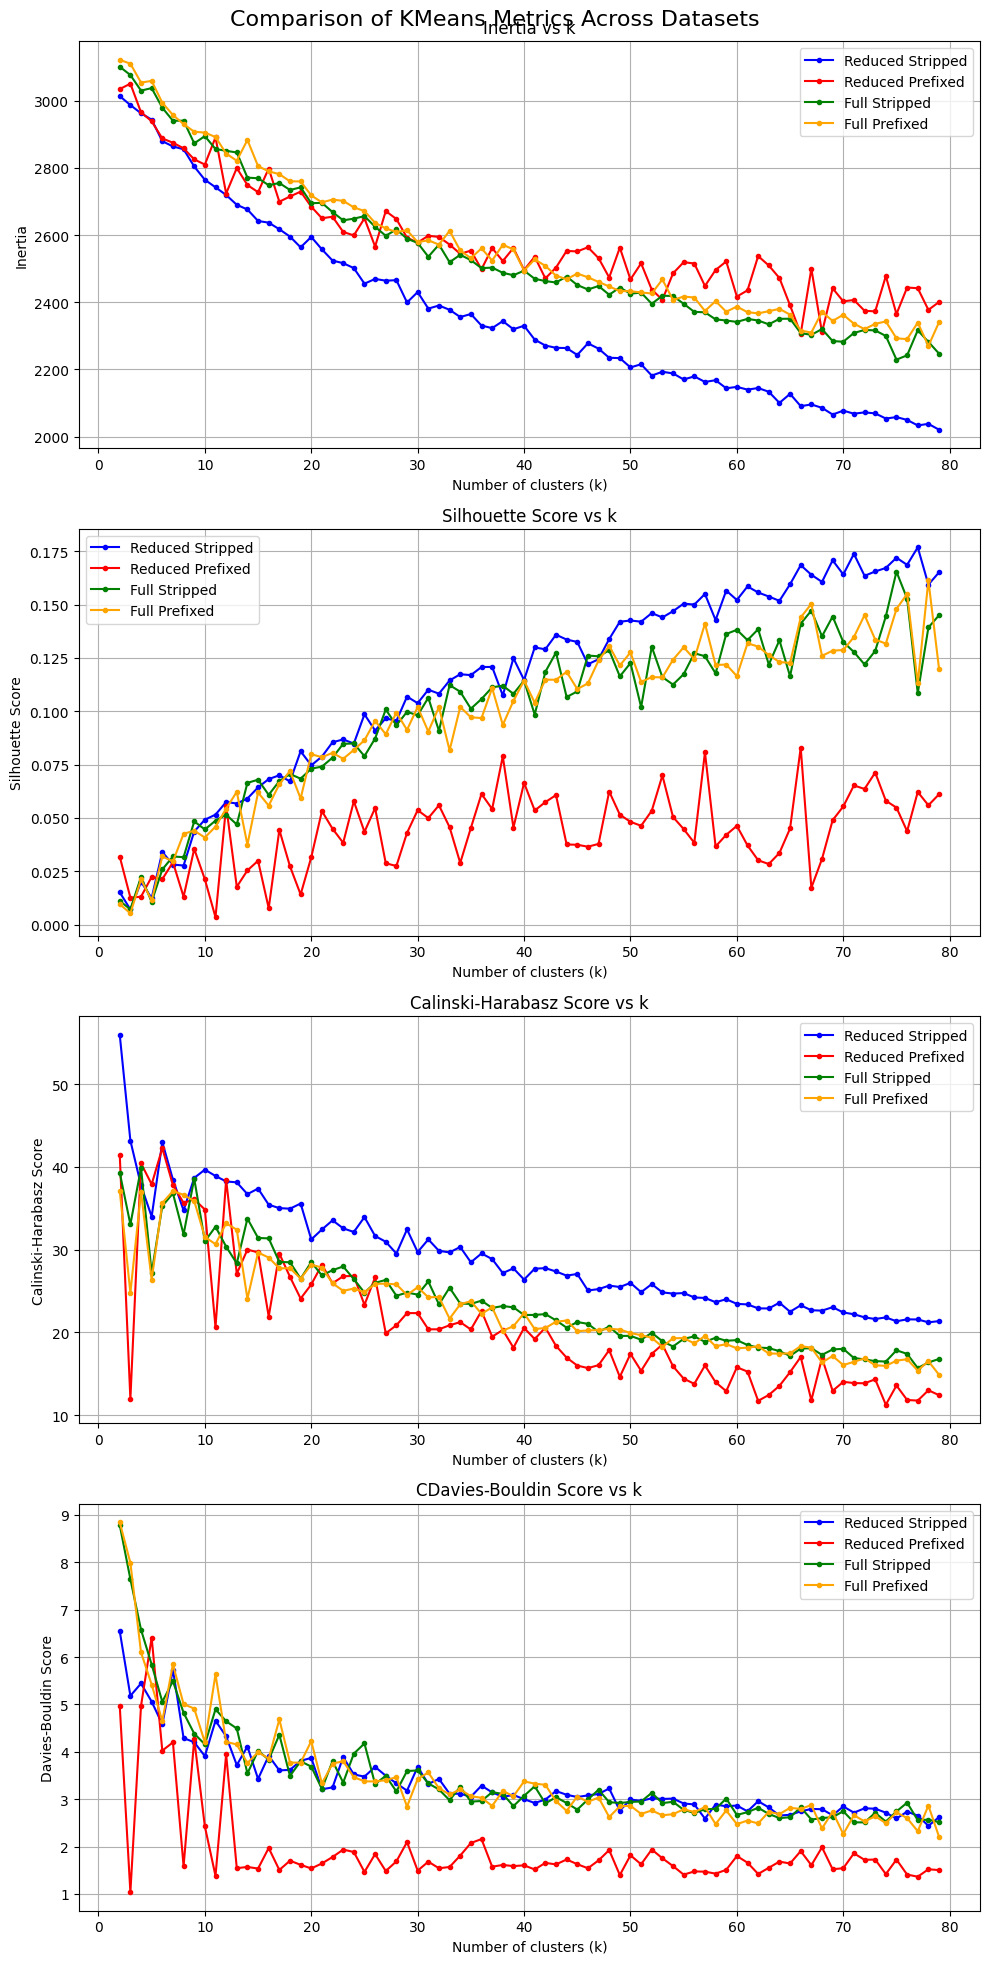

In [7]:
colors = {
    "Reduced Stripped": 'blue',
    "Reduced Prefixed": 'red',
    "Full Stripped": 'green',
    "Full Prefixed": 'orange',
}

fig, axes = plt.subplots(4, 1, figsize=(10, 20))

ax = axes[0]
for name, metrics in kmeans.items():
    ax.plot(k_range_km, metrics['inertia'], marker='o', markersize=3, label=name, color=colors[name])
ax.set_title('Inertia vs k')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
ax.grid(True)
ax.legend()

ax = axes[1]
for name, metrics in kmeans.items():
    ax.plot(k_range_km, metrics['silhouette'], marker='o', markersize=3, label=name, color=colors[name])
ax.set_title('Silhouette Score vs k')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.grid(True)
ax.legend()

ax = axes[2]
for name, metrics in kmeans.items():
    ax.plot(k_range_km, metrics['calinski'], marker='o', markersize=3, label=name, color=colors[name])
ax.set_title('Calinski-Harabasz Score vs k')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Calinski-Harabasz Score')
ax.grid(True)
ax.legend()

ax = axes[3]
for name, metrics in kmeans.items():
    ax.plot(k_range_km, metrics['davies'], marker='o', markersize=3, label=name, color=colors[name])
ax.set_title('CDavies-Bouldin Score vs k')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Davies-Bouldin Score')
ax.grid(True)
ax.legend()

plt.suptitle('Comparison of KMeans Metrics Across Datasets', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join('figures_and_tables', "kmeans_dataset_comparison.png"))
plt.show()

### Konacni modeli

In [8]:
km_reduced_final = KMeans(n_clusters=38, random_state=8, n_init=50)
cluster_labels_reduced_km = km_reduced_final.fit_predict(X_lsa_reduced_stripped)

In [9]:
km_full_final = KMeans(n_clusters=38, random_state=8, n_init=50)
cluster_labels_full_km = km_full_final.fit_predict(X_lsa_full_stripped)

### Analiza klastera

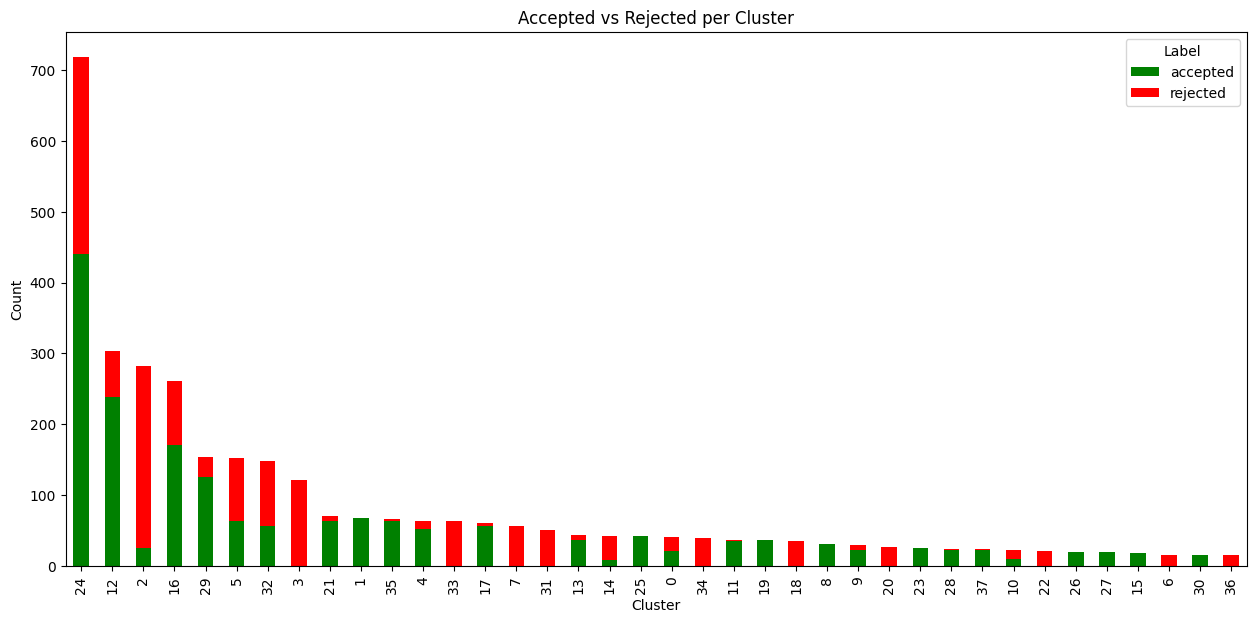

true_label,accepted,rejected,total,pct_accepted,top_terms
cluster,,,,,
1,68,0,68,100.000000,"law, veterinary, justanswer, avatar, jpg, veterinarian, upload, appliance, positive, accept"
30,15,0,15,100.000000,"kitten, cat, identification, neuter, rescue, club, tag, behavior, adoption, checklist"
25,43,0,43,100.000000,"platinum, athletic, performance, pak, reproduction, hoof, equine, density, allergy, metabolic"
19,36,0,36,100.000000,"pet, supply, trust, rabbit, drsfostersmith, foster, guinea, cage, smith, name"
15,18,0,18,100.000000,"goat, dairy, fence, raise, acreage, subscription, beautiful, magazine, country, pond"
8,31,0,31,100.000000,"poultry, geese, chicken, coop, backyard, acreage, raise, duck, country, bantam"
26,20,0,20,100.000000,"hobby, livestock, poultry, farm, alpaca, post, coop, thread, hydraulic, backyard"
27,20,0,20,100.000000,"hunt, deer, goose, predator, creek, call, game, fox, electronic, sound"
23,25,1,26,96.200000,"classifi, agriculture, ag, livestock, machinery, hog, deere, classify, buyer, crop"


In [16]:
show_cluster_composition(cluster_labels_reduced_km, X_tfidf_reduced_stripped, feature_names_reduced_stripped, 38)

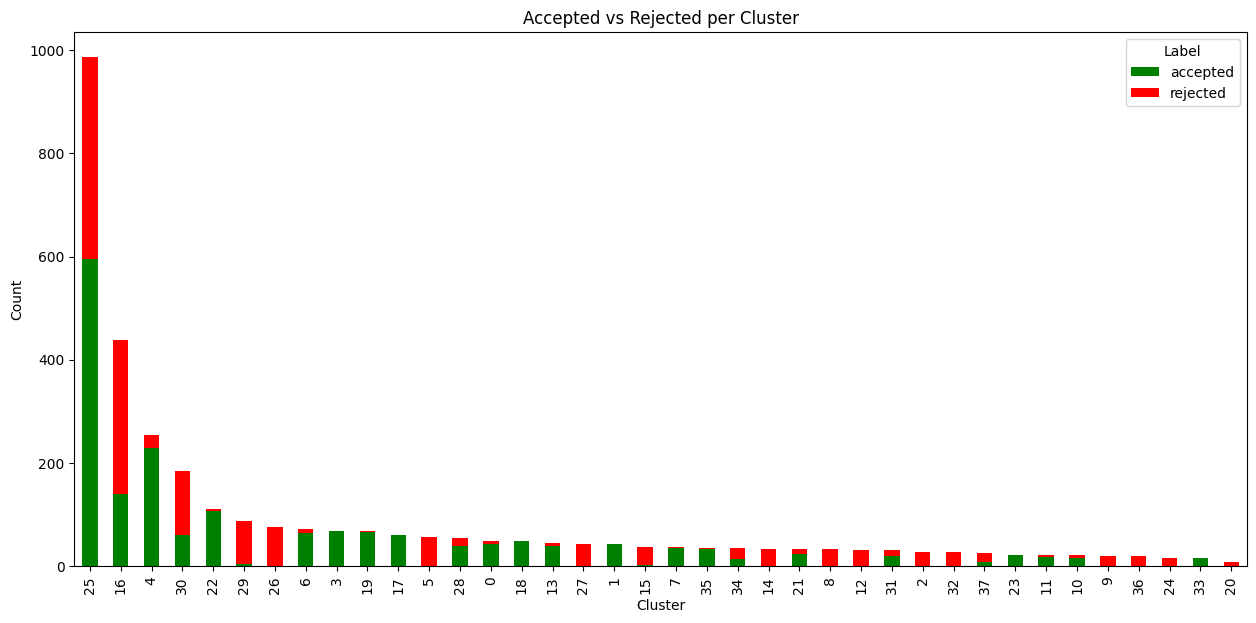

true_label,accepted,rejected,total,pct_accepted,top_terms
cluster,,,,,
1,43,0,43,100.000000,"platinum, athletic, performance, pak, reproduction, hoof, equine, density, allergy, metabolic"
3,68,0,68,100.000000,"law, veterinary, justanswer, avatar, jpg, veterinarian, upload, appliance, positive, accept"
23,22,0,22,100.000000,"yoplait, smoothie, loser, biggest, smoothy, nbc, tuesday, frozen, idea, cool"
33,15,0,15,100.000000,"trust, pet, supply, guinea, rabbit, drsfostersmith, found, name, pig, save"
18,49,0,49,100.000000,"acreage, raise, poultry, country, beautiful, subscription, chicken, magazine, pond, backyard"
19,66,1,67,98.500000,"hunt, deer, game, sound, cass, hunter, call, goose, creek, predator"
17,60,1,61,98.400000,"livestock, classifi, farm, post, agriculture, ag, classify, breed, kitten, book"
35,33,1,34,97.100000,"cage, pet, supply, ferret, reptile, litter, bird, clearance, pond, dog"
22,107,4,111,96.400000,"dog, pet, cat, vet, veterinarian, food, asap, groome, care, petplan"


In [17]:
show_cluster_composition(cluster_labels_full_km, X_tfidf_full_stripped, feature_names_full_stripped, 38)

In [18]:
clustering_results.append({
    'Algorithm': 'KMeans',
    'Dataset': 'Reduced Stripped',
    'Number of Clusters': 38,
    'Silhouette': silhouette_score(X_lsa_reduced_stripped, cluster_labels_reduced_km, sample_size=1000, random_state=8),
    'Calinski‑Harabasz': calinski_harabasz_score(X_lsa_reduced_stripped, cluster_labels_reduced_km),
    'Davies-Bouldin': davies_bouldin_score(X_lsa_reduced_stripped, cluster_labels_reduced_km)
})

clustering_results.append({
    'Algorithm': 'KMeans',
    'Dataset': 'Full Stripped',
    'Number of Clusters': 38,
    'Silhouette': silhouette_score(X_lsa_full_stripped, cluster_labels_full_km, sample_size=1000, random_state=8),
    'Calinski‑Harabasz': calinski_harabasz_score(X_lsa_full_stripped, cluster_labels_full_km),
    'Davies-Bouldin': davies_bouldin_score(X_lsa_full_stripped, cluster_labels_full_km)
})

## Algoritam 2: Bisekcija k sredina
### Odredjujemo k i strategiju deljenja

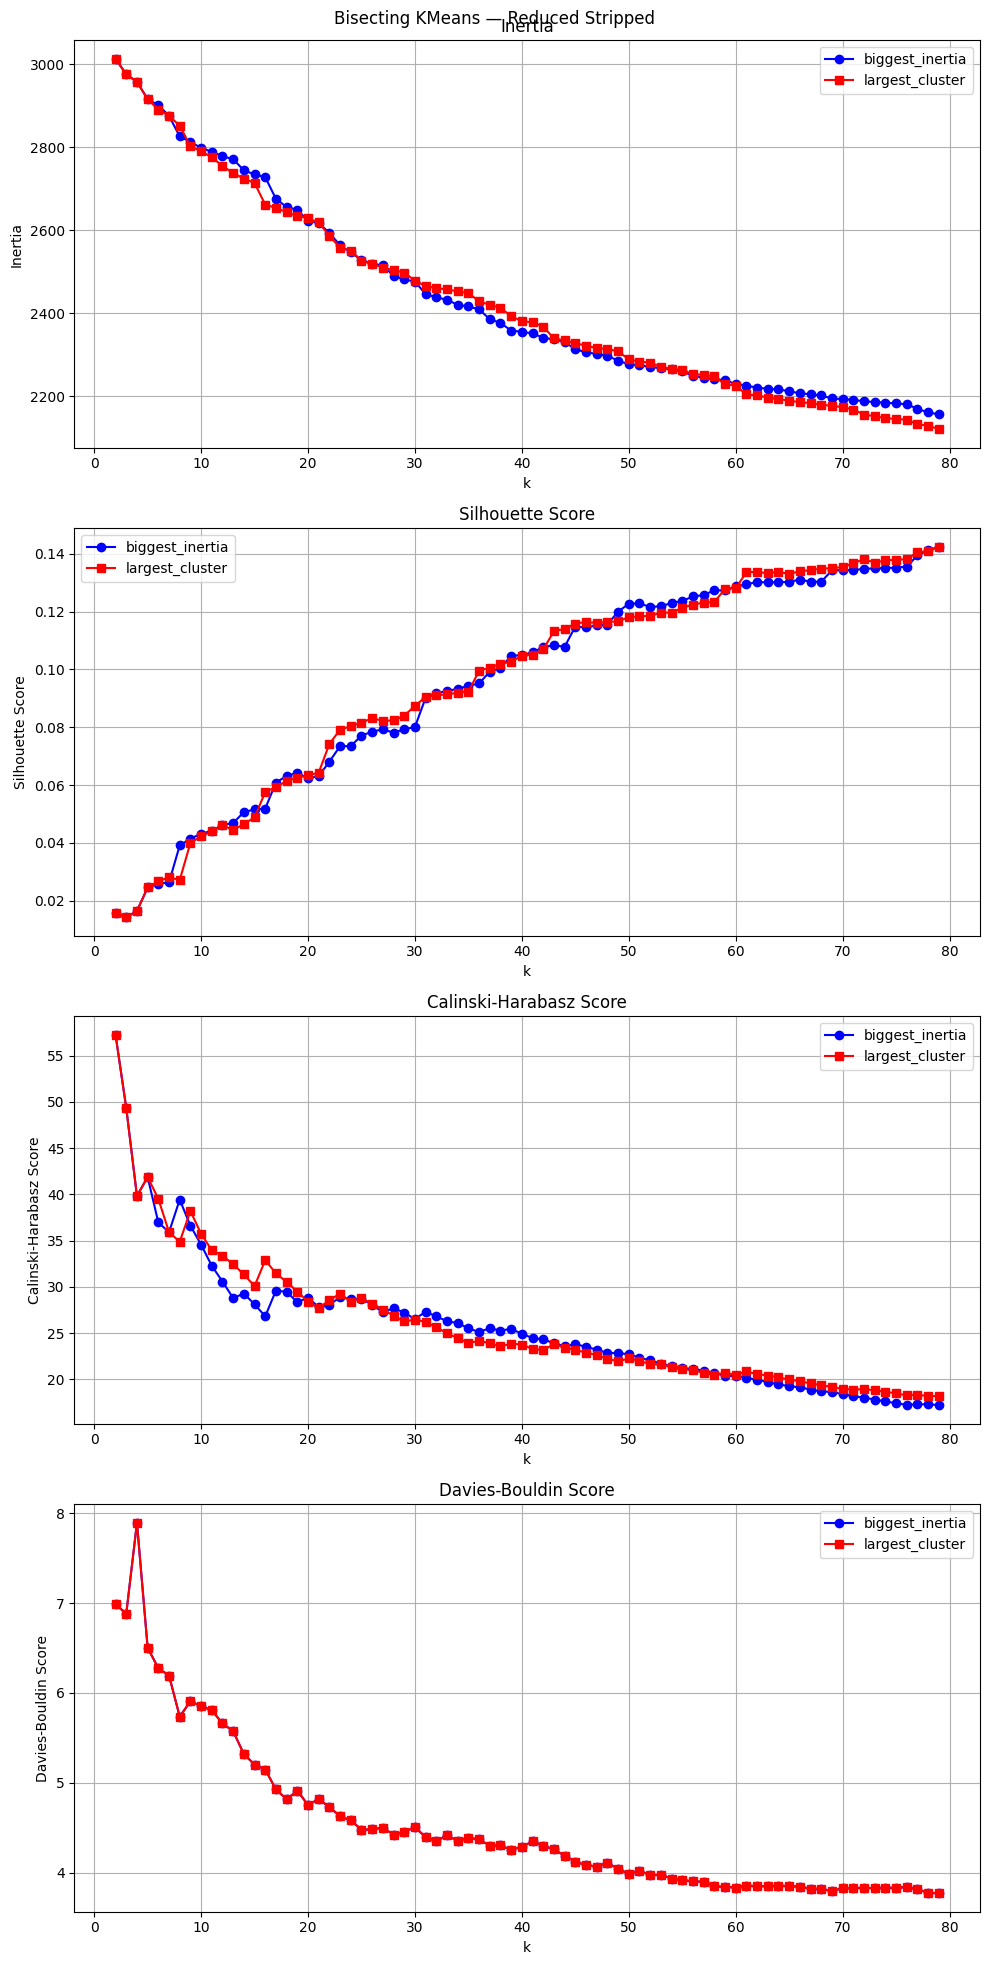

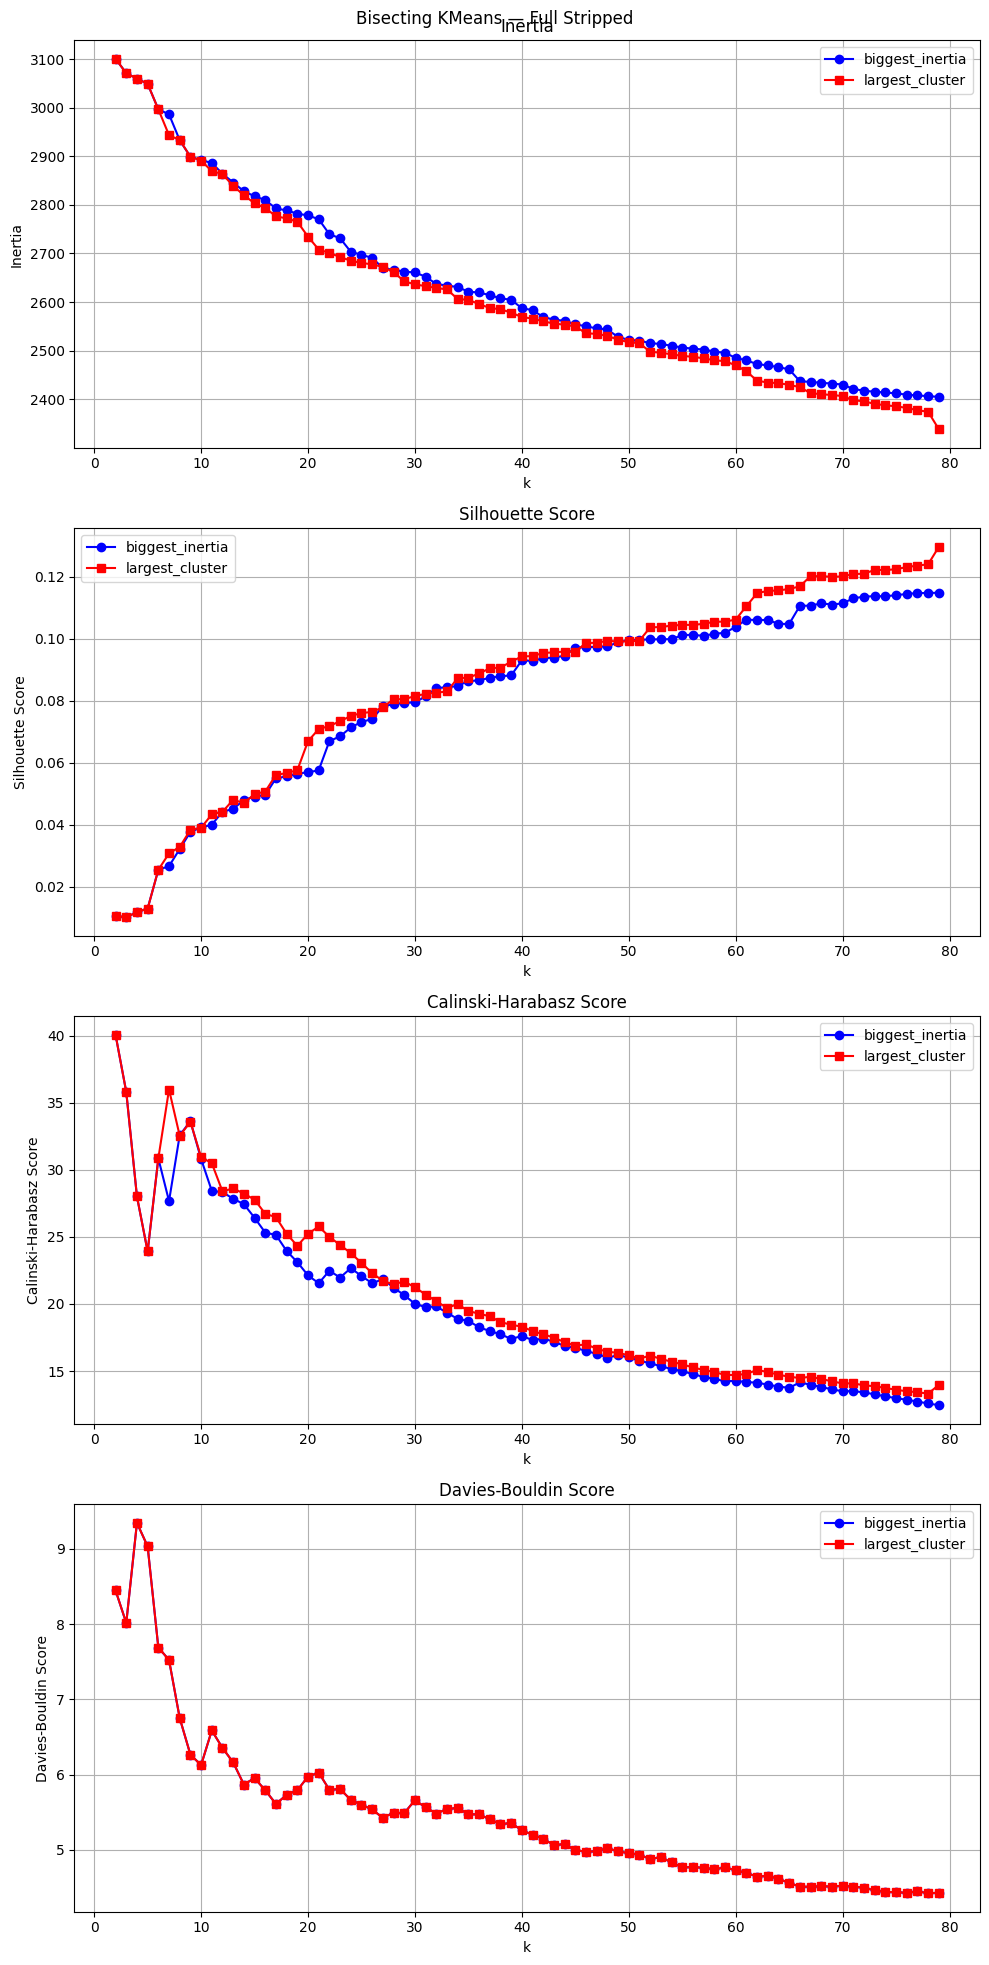

In [20]:
bisecting_kmeans = {}
k_range_bisect = range(2, 80)

for name, X_data in datasets_stripped.items():
    strategies = {
        "biggest_inertia": {"silhouette": [], "inertia": [], "calinski": [], "davies": []},
        "largest_cluster": {"silhouette": [], "inertia": [], "calinski": [], "davies": []}
    }

    for k in k_range_bisect:
        bisect_inertia = BisectingKMeans(
            n_clusters=k,
            bisecting_strategy='biggest_inertia',
            random_state=8,
            n_init=10
        )
        preds_inertia = bisect_inertia.fit_predict(X_data)
        strategies["biggest_inertia"]["inertia"].append(bisect_inertia.inertia_)
        strategies["biggest_inertia"]["silhouette"].append(
            silhouette_score(X_data, preds_inertia, sample_size=1000, random_state=8)
        )
        strategies["biggest_inertia"]["calinski"].append(
            calinski_harabasz_score(X_data, preds_inertia)
        )
        strategies["biggest_inertia"]["davies"].append(
            davies_bouldin_score(X_data, preds_inertia)
        )

        bisect_cluster = BisectingKMeans(
            n_clusters=k,
            bisecting_strategy='largest_cluster',
            random_state=8,
            n_init=10
        )
        preds_cluster = bisect_cluster.fit_predict(X_data)
        strategies["largest_cluster"]["inertia"].append(bisect_cluster.inertia_)
        strategies["largest_cluster"]["silhouette"].append(
            silhouette_score(X_data, preds_cluster, sample_size=1000, random_state=8)
        )
        strategies["largest_cluster"]["calinski"].append(
            calinski_harabasz_score(X_data, preds_cluster)
        )
        strategies["largest_cluster"]["davies"].append(
            davies_bouldin_score(X_data, preds_inertia)
        )

    bisecting_kmeans[name] = strategies

    fig, axes = plt.subplots(4, 1, figsize=(10, 20))

    axes[0].plot(k_range_bisect, strategies["biggest_inertia"]["inertia"], 'b-o', label='biggest_inertia')
    axes[0].plot(k_range_bisect, strategies["largest_cluster"]["inertia"], 'r-s', label='largest_cluster')
    axes[0].set_title('Inertia')
    axes[0].set_xlabel('k')
    axes[0].set_ylabel('Inertia')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(k_range_bisect, strategies["biggest_inertia"]["silhouette"], 'b-o', label='biggest_inertia')
    axes[1].plot(k_range_bisect, strategies["largest_cluster"]["silhouette"], 'r-s', label='largest_cluster')
    axes[1].set_title('Silhouette Score')
    axes[1].set_xlabel('k')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(k_range_bisect, strategies["biggest_inertia"]["calinski"], 'b-o', label='biggest_inertia')
    axes[2].plot(k_range_bisect, strategies["largest_cluster"]["calinski"], 'r-s', label='largest_cluster')
    axes[2].set_title('Calinski-Harabasz Score')
    axes[2].set_xlabel('k')
    axes[2].set_ylabel('Calinski-Harabasz Score')
    axes[2].grid(True)
    axes[2].legend()

    axes[3].plot(k_range_bisect, strategies["biggest_inertia"]["davies"], 'b-o', label='biggest_inertia')
    axes[3].plot(k_range_bisect, strategies["largest_cluster"]["davies"], 'r-s', label='largest_cluster')
    axes[3].set_title('Davies-Bouldin Score')
    axes[3].set_xlabel('k')
    axes[3].set_ylabel('Davies-Bouldin Score')
    axes[3].grid(True)
    axes[3].legend()

    plt.suptitle(f'Bisecting KMeans — {name}')
    plt.tight_layout()
    plt.show()

### Konacni modeli

In [21]:
bisecting_reduced_final = BisectingKMeans(n_clusters=38, random_state=8, n_init=50, bisecting_strategy='largest_cluster')
cluster_labels_reduced_bisecting = bisecting_reduced_final.fit_predict(X_lsa_reduced_stripped)

In [22]:
bisecting_full_final = BisectingKMeans(n_clusters=38, random_state=8, n_init=50, bisecting_strategy='largest_cluster')
cluster_labels_full_bisecting = bisecting_full_final.fit_predict(X_lsa_full_stripped)

### Analiza klastera

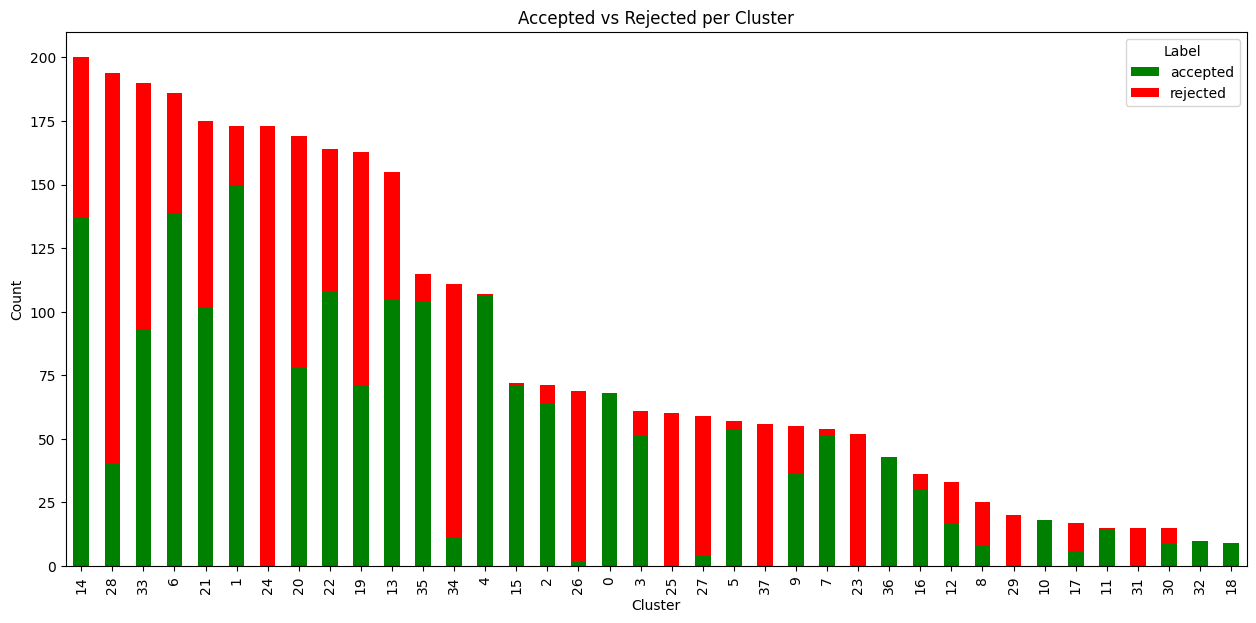

true_label,accepted,rejected,total,pct_accepted,top_terms
cluster,,,,,
0,68,0,68,100.000000,"law, veterinary, justanswer, avatar, jpg, veterinarian, upload, appliance, positive, accept"
10,18,0,18,100.000000,"website, build, business, create, software, design, minute, customer, drag, custom"
36,43,0,43,100.000000,"platinum, athletic, performance, pak, reproduction, hoof, equine, density, allergy, metabolic"
32,10,0,10,100.000000,"remedy, flu, ailment, hair, throat, steam, chest, herbal, congestion, various"
18,9,0,9,100.000000,"false, truck, tx, tn, ok, june, oh, july, fl, august"
4,106,1,107,99.100000,"livestock, poultry, coop, chicken, backyard, farm, breed, raise, subscribe, subscription"
15,71,1,72,98.600000,"sale, puppy, alpaca, breeder, breed, bull, cattle, herd, farm, ranch"
5,54,3,57,94.700000,"soap, oil, handmade, bath, natural, milk, goat, skin, scent, lotion"
7,51,3,54,94.400000,"recipe, cheese, delicious, cook, dessert, cream, bak, flavor, bread, salad"


In [23]:
show_cluster_composition(cluster_labels_reduced_bisecting, X_tfidf_reduced_stripped, feature_names_reduced_stripped, 38)

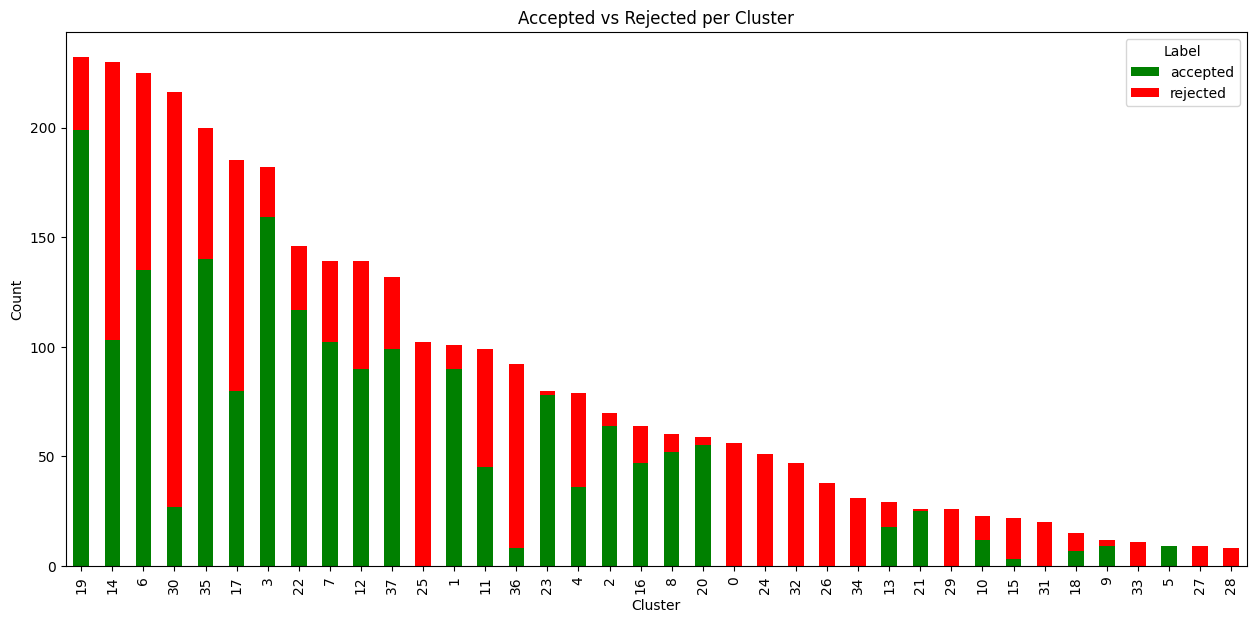

true_label,accepted,rejected,total,pct_accepted,top_terms
cluster,,,,,
5,9,0,9,100.000000,"nan, false, truck, tx, tn, wv, orlean, ok, june, nashville"
23,78,2,80,97.500000,"platinum, athletic, performance, weight, pak, reproduction, hoof, equine, support, density"
21,25,1,26,96.200000,"classifi, agriculture, ag, livestock, machinery, hog, deere, classify, buyer, crop"
20,55,4,59,93.200000,"soap, oil, natural, handmade, bath, milk, goat, skin, lotion, scent"
2,64,6,70,91.400000,"alert, oop, visibility, exist, newly, upper, unable, list, invalid, private"
1,90,11,101,89.100000,"nj, poultry, livestock, mi, city, feed, review, farm, brunswick, piscataway"
3,159,23,182,87.400000,"rabbit, pet, supply, compare, toy, shop, save, price, result, yahoo"
8,52,8,60,86.700000,"puppy, sale, bull, cattle, breeder, breed, akc, hereford, ranch, heifer"
19,199,33,232,85.800000,"food, recipe, organic, cheese, milk, natural, goat, meal, ingredient, dairy"


In [24]:
show_cluster_composition(cluster_labels_full_bisecting, X_tfidf_full_stripped, feature_names_full_stripped, 38)

In [25]:
clustering_results.append({
    'Algorithm': 'Bisecting KMeans',
    'Dataset': 'Reduced Stripped',
    'Number of Clusters': 38,
    'Silhouette': silhouette_score(X_lsa_reduced_stripped, cluster_labels_reduced_bisecting, sample_size=1000, random_state=8),
    'Calinski‑Harabasz': calinski_harabasz_score(X_lsa_reduced_stripped, cluster_labels_reduced_bisecting),
    'Davies-Bouldin': davies_bouldin_score(X_lsa_reduced_stripped, cluster_labels_reduced_bisecting)
    
})

clustering_results.append({
    'Algorithm': 'Bisecting KMeans',
    'Dataset': 'Full Stripped',
    'Number of Clusters': 38,
    'Silhouette': silhouette_score(X_lsa_full_stripped, cluster_labels_full_bisecting, sample_size=1000, random_state=8),
    'Calinski‑Harabasz': calinski_harabasz_score(X_lsa_full_stripped, cluster_labels_full_bisecting),
    'Davies-Bouldin': davies_bouldin_score(X_lsa_full_stripped, cluster_labels_full_bisecting)
})

## Algoritam 3: Aglomerativno klasterovanje 
### Pravimo dendogram na osnovu kojeg odredjujemo broj klastera

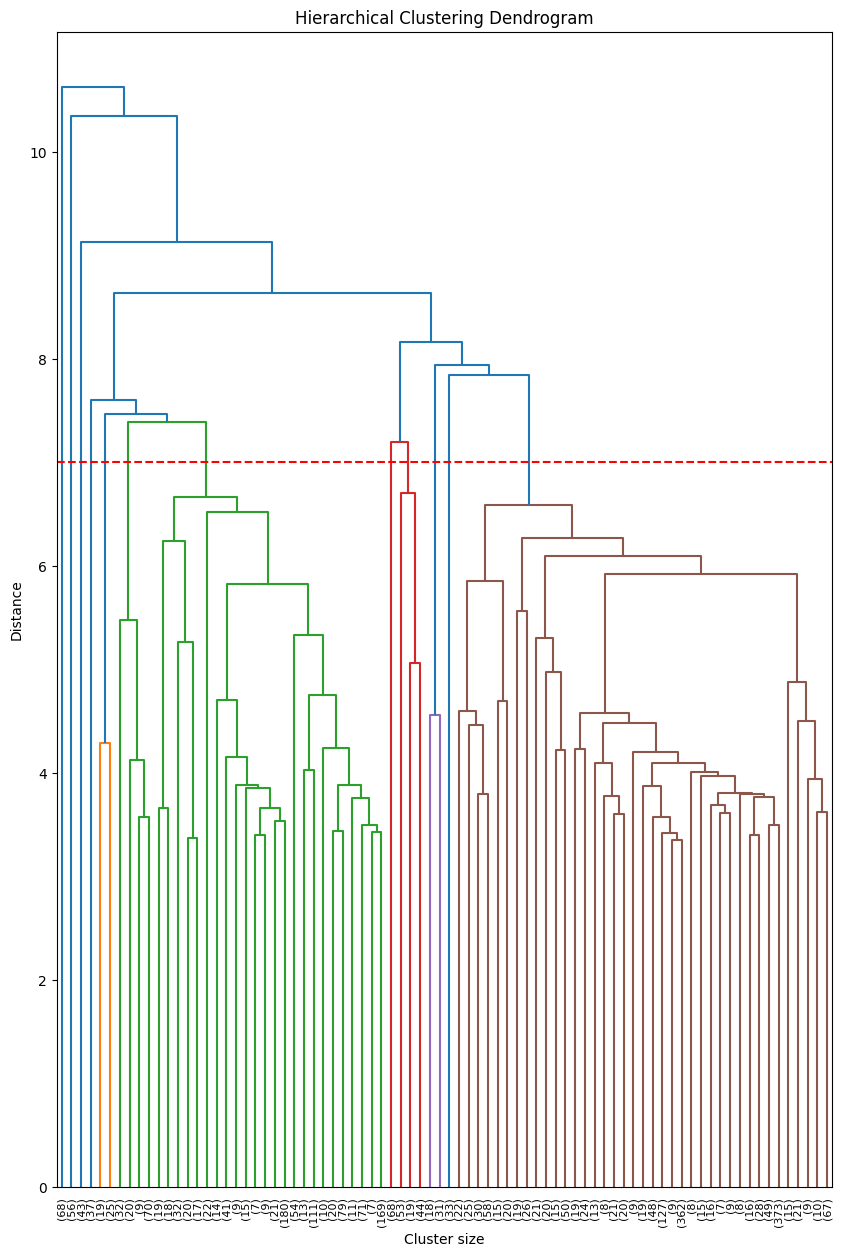

In [26]:
linkage_reduced_stripped = linkage(X_lsa_reduced_stripped, method='ward', metric='euclidean')

plt.figure(figsize=(10, 15))
dendrogram(
    linkage_reduced_stripped,
    truncate_mode='lastp',   
    p=80,                    
    leaf_rotation=90,
    leaf_font_size=8,
)
plt.axhline(y=7.0, color="r", linestyle="--")
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.show()

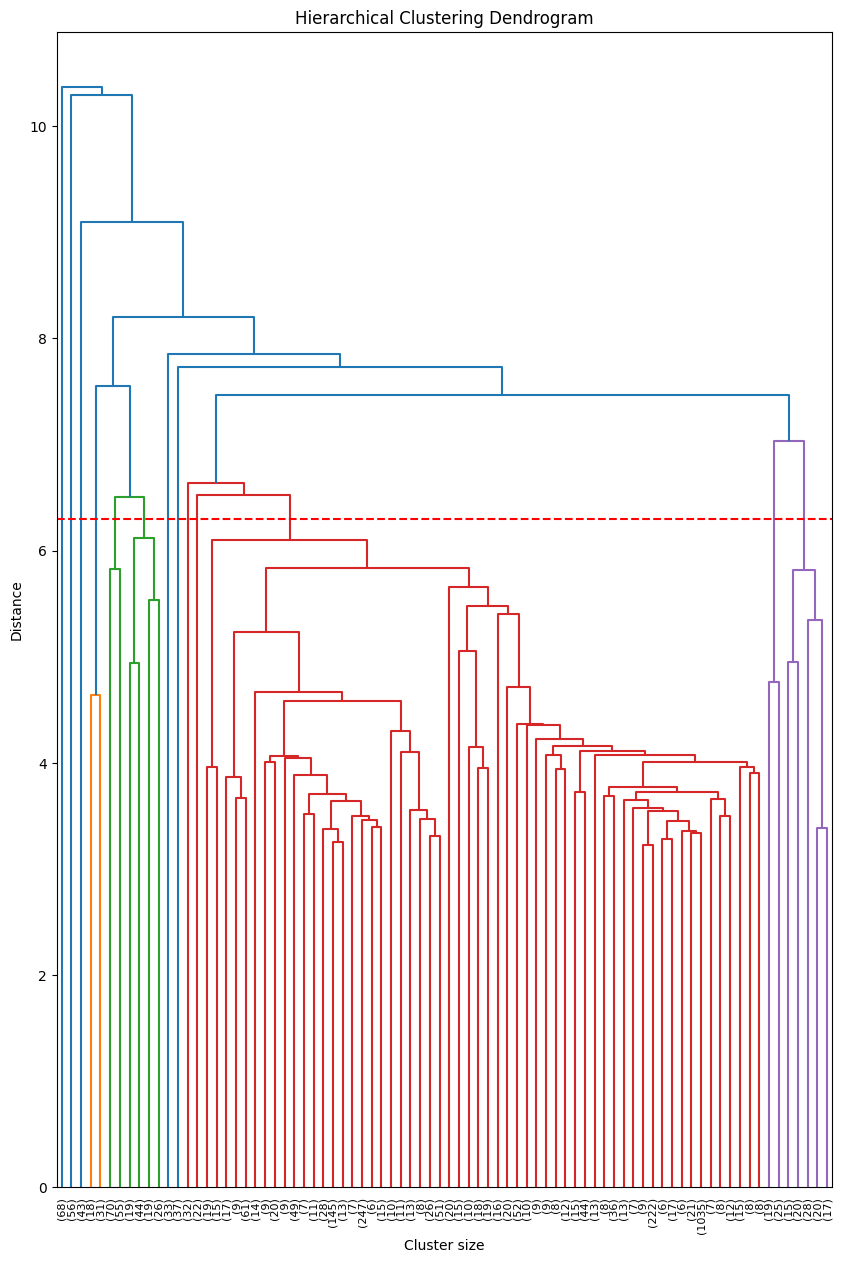

In [27]:
linkage_full_stripped = linkage(X_lsa_full_stripped, method='ward', metric='euclidean')

plt.figure(figsize=(10, 15))
dendrogram(
    linkage_full_stripped,
    truncate_mode='lastp',   
    p=80,                    
    leaf_rotation=90,
    leaf_font_size=8,
)
plt.axhline(y=6.3, color="r", linestyle="--")
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.show()

### Konacni modeli

In [28]:
ac_reduced_stripped = AgglomerativeClustering(n_clusters=12, linkage='ward')
ac_cluster_reduced_labels = ac_reduced_stripped.fit_predict(X_lsa_reduced_stripped)

ac_full_stripped = AgglomerativeClustering(n_clusters=13, linkage='ward')
ac_cluster_full_labels = ac_full_stripped.fit_predict(X_lsa_full_stripped)

### Analiza klastera

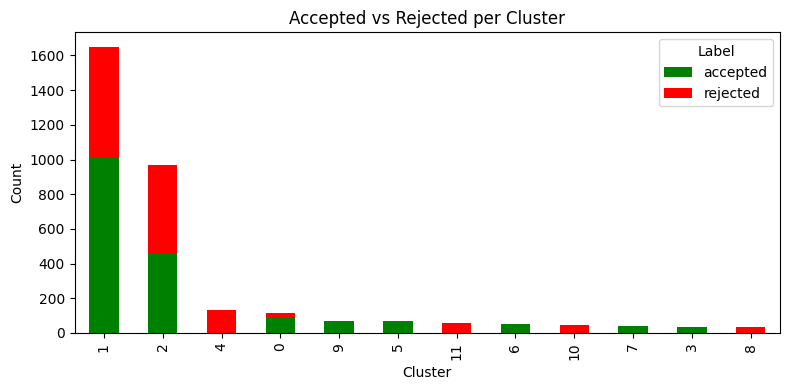

true_label,accepted,rejected,total,pct_accepted,top_terms
cluster,,,,,
6,49,0,49,100.000000,"acreage, raise, poultry, country, beautiful, subscription, chicken, magazine, pond, backyard"
9,68,0,68,100.000000,"law, veterinary, justanswer, avatar, jpg, veterinarian, upload, appliance, positive, accept"
7,43,0,43,100.000000,"platinum, athletic, performance, pak, reproduction, hoof, equine, density, allergy, metabolic"
3,35,2,37,94.600000,"acai, berry, colon, julia, trial, cleanse, diet, lost, week, lose"
5,62,6,68,91.200000,"alert, oop, visibility, exist, newly, upper, unable, list, private, invalid"
0,89,27,116,76.700000,"yahoo, review, compare, result, deal, write, amazon, coupon, shop, price"
1,1007,644,1651,61.000000,"found, sale, pet, farm, business, price, call, email, supply, equipment"
2,454,515,969,46.900000,"health, disease, symptom, treatment, diet, healthy, body, weight, cause, food"
4,2,129,131,1.500000,"ivf, donor, fertility, sperm, egg, attain, cycle, bank, infertility, success"


In [29]:
show_cluster_composition(ac_cluster_reduced_labels, X_tfidf_reduced_stripped, feature_names_reduced_stripped, 12)

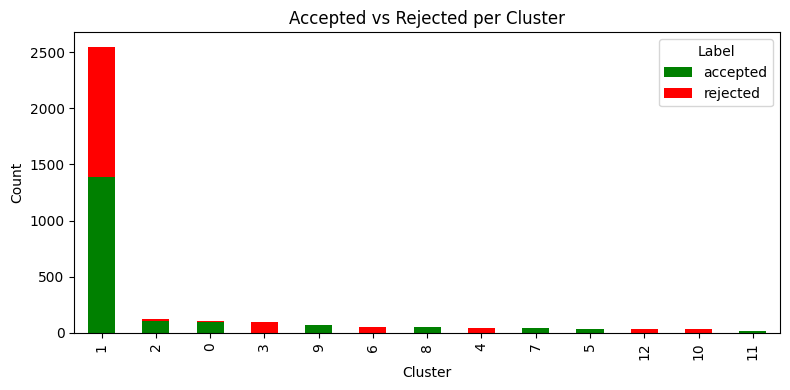

true_label,accepted,rejected,total,pct_accepted,top_terms
cluster,,,,,
8,49,0,49,100.000000,"acreage, raise, poultry, country, beautiful, subscription, chicken, magazine, pond, backyard"
9,68,0,68,100.000000,"law, veterinary, justanswer, avatar, jpg, veterinarian, upload, appliance, positive, accept"
11,22,0,22,100.000000,"yoplait, smoothie, loser, biggest, smoothy, nbc, tuesday, frozen, idea, cool"
7,43,0,43,100.000000,"platinum, athletic, performance, pak, reproduction, hoof, equine, density, allergy, metabolic"
5,35,2,37,94.600000,"acai, berry, colon, julia, trial, cleanse, diet, lost, week, lose"
0,96,12,108,88.900000,"livestock, farm, review, nj, classifi, post, mi, feed, brunswick, piscataway"
2,103,22,125,82.400000,"compare, amazon, yahoo, rabbit, price, review, deal, shop, result, merchant"
1,1391,1157,2548,54.600000,"found, treatment, health, care, food, disease, call, pet, time, email"
3,2,98,100,2.000000,"cancer, mesothelioma, arthritis, lung, symptom, health, rheumatoid, crohn, treatment, disease"


In [30]:
show_cluster_composition(ac_cluster_full_labels, X_tfidf_full_stripped, feature_names_full_stripped, 13)

In [31]:
ac_sil_reduced = silhouette_score(X_lsa_reduced_stripped, ac_cluster_reduced_labels, sample_size=1000, random_state=8)
ac_cal_reduced = calinski_harabasz_score(X_lsa_reduced_stripped, ac_cluster_reduced_labels)
ac_dav_reduced = davies_bouldin_score(X_lsa_reduced_stripped, ac_cluster_reduced_labels)

ac_sil_full = silhouette_score(X_lsa_full_stripped, ac_cluster_full_labels, sample_size=1000, random_state=8)
ac_cal_full = calinski_harabasz_score(X_lsa_full_stripped, ac_cluster_full_labels)
ac_dav_full = davies_bouldin_score(X_lsa_full_stripped, ac_cluster_full_labels)


clustering_results.append({
    'Algorithm': 'Agglomerative clustering',
    'Dataset': 'Reduced Stripped',
    'Number of Clusters': 12,
    'Silhouette': silhouette_score(X_lsa_reduced_stripped, ac_cluster_reduced_labels, sample_size=1000, random_state=8),
    'Calinski‑Harabasz': calinski_harabasz_score(X_lsa_reduced_stripped, ac_cluster_reduced_labels),
    'Davies-Bouldin': davies_bouldin_score(X_lsa_reduced_stripped, ac_cluster_reduced_labels)
})

clustering_results.append({
    'Algorithm': 'Agglomerative clustering',
    'Dataset': 'Full Stripped',
    'Number of Clusters': 13,
    'Silhouette': silhouette_score(X_lsa_full_stripped, ac_cluster_full_labels, sample_size=1000, random_state=8),
    'Calinski‑Harabasz': calinski_harabasz_score(X_lsa_full_stripped, ac_cluster_full_labels),
    'Davies-Bouldin': davies_bouldin_score(X_lsa_full_stripped, ac_cluster_full_labels)
})

In [32]:
clustering_results[-1]

{'Algorithm': 'Agglomerative clustering',
 'Dataset': 'Full Stripped',
 'Number of Clusters': 13,
 'Silhouette': 0.06553650317402138,
 'Calinski‑Harabasz': 38.23504659805607,
 'Davies-Bouldin': 2.1345682951163885}

In [33]:
clustering_results[-2]

{'Algorithm': 'Agglomerative clustering',
 'Dataset': 'Reduced Stripped',
 'Number of Clusters': 12,
 'Silhouette': 0.0541818194486629,
 'Calinski‑Harabasz': 43.66511874391443,
 'Davies-Bouldin': 3.025490848740874}

## Model 4: HDBSCAN:

In [35]:
all_scan_results = {}

for dataset_name, X_data in datasets_stripped.items():
    print(f"\n{'='*70}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*70}")
    
    min_cluster_sizes = [2, 5, 10, 15, 20, 30, 50, 75, 100]
    min_samples_vals  = [2, 5, 10, 15, None]   
    
    scan_results = []
    
    print("\nScanning parameters:")
    print(f"{'min_cluster_size':>18}  {'min_samples':>12}  {'n_clusters':>10}  "
          f"{'noise_pct':>10}  {'silhouette':>12}")
    
    for mcs in min_cluster_sizes:
        for ms in min_samples_vals:
            ms_val = ms if ms is not None else mcs
            
            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=mcs,
                min_samples=ms_val,
                metric='euclidean',
            )                                     
            preds = clusterer.fit_predict(X_data)
            
            n_clusters  = len(set(preds)) - (1 if -1 in preds else 0)
            noise_count = (preds == -1).sum()
            noise_pct   = noise_count / len(preds) * 100
            
            non_noise_mask = preds != -1
            if n_clusters >= 2 and non_noise_mask.sum() > n_clusters:
                sil = silhouette_score(X_data[non_noise_mask], preds[non_noise_mask],
                                       sample_size=1000, random_state=8)
            else:
                sil = np.nan
            
            scan_results.append({
                'min_cluster_size': mcs,
                'min_samples':      ms_val,
                'n_clusters':       n_clusters,
                'noise_pct':        noise_pct,
                'silhouette':       sil,
                'preds':            preds,
                'clusterer':        clusterer
            })
            
            ms_label = f"{ms_val} (=mcs)" if ms is None else str(ms_val)
            sil_str  = f"{sil:.4f}" if not np.isnan(sil) else "N/A"
            print(f"{mcs:>18}  {ms_label:>12}  {n_clusters:>10}  "
                  f"{noise_pct:>9.1f}%  {sil_str:>12}")
    
    all_scan_results[dataset_name] = scan_results


Dataset: Reduced Stripped

Scanning parameters:
  min_cluster_size   min_samples  n_clusters   noise_pct    silhouette
                 2             2         386       38.8%        0.4592
                 2             5         133       52.6%        0.5270
                 2            10          64       63.2%        0.5204
                 2            15          46       69.9%        0.5399
                 2      2 (=mcs)         386       38.8%        0.4592
                 5             2         164       44.3%        0.4878
                 5             5         109       52.6%        0.5310
                 5            10          56       63.5%        0.5281
                 5            15          35       70.4%        0.5494
                 5      5 (=mcs)         109       52.6%        0.5310
                10             2          71       51.5%        0.4219
                10             5          62       58.3%        0.4875
                10          

In [36]:
clustering_results.append({
    'Algorithm': 'HDBSCAN',
    'Dataset': 'Reduced Stripped',
    'Number of Clusters': None,
    'Silhouette': None,
    'Calinski‑Harabasz': None,
    'Davies-Bouldin': None
})
clustering_results.append({
    'Algorithm': 'HDBSCAN',
    'Dataset': 'Full Stripped',
    'Number of Clusters': None,
    'Silhouette': None,
    'Calinski‑Harabasz': None,
    'Davies-Bouldin': None
})

## Model 5: Gaussian mixture model

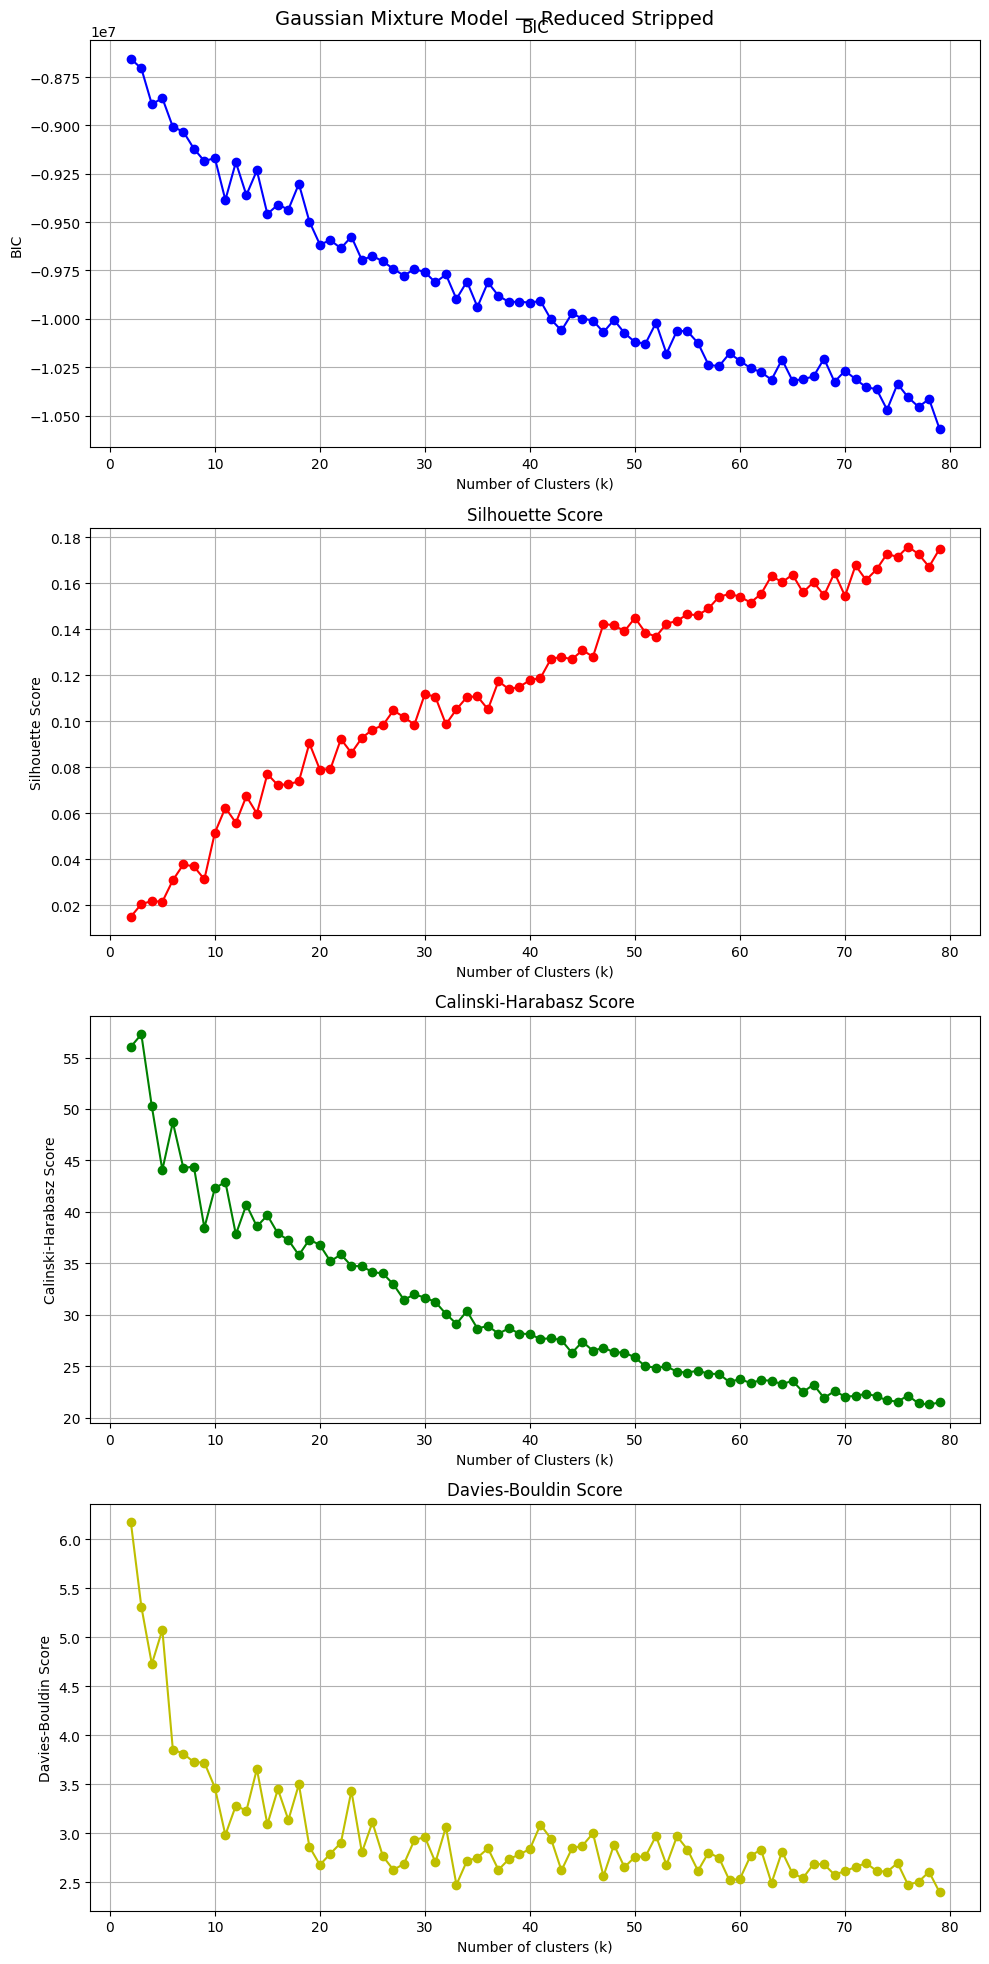

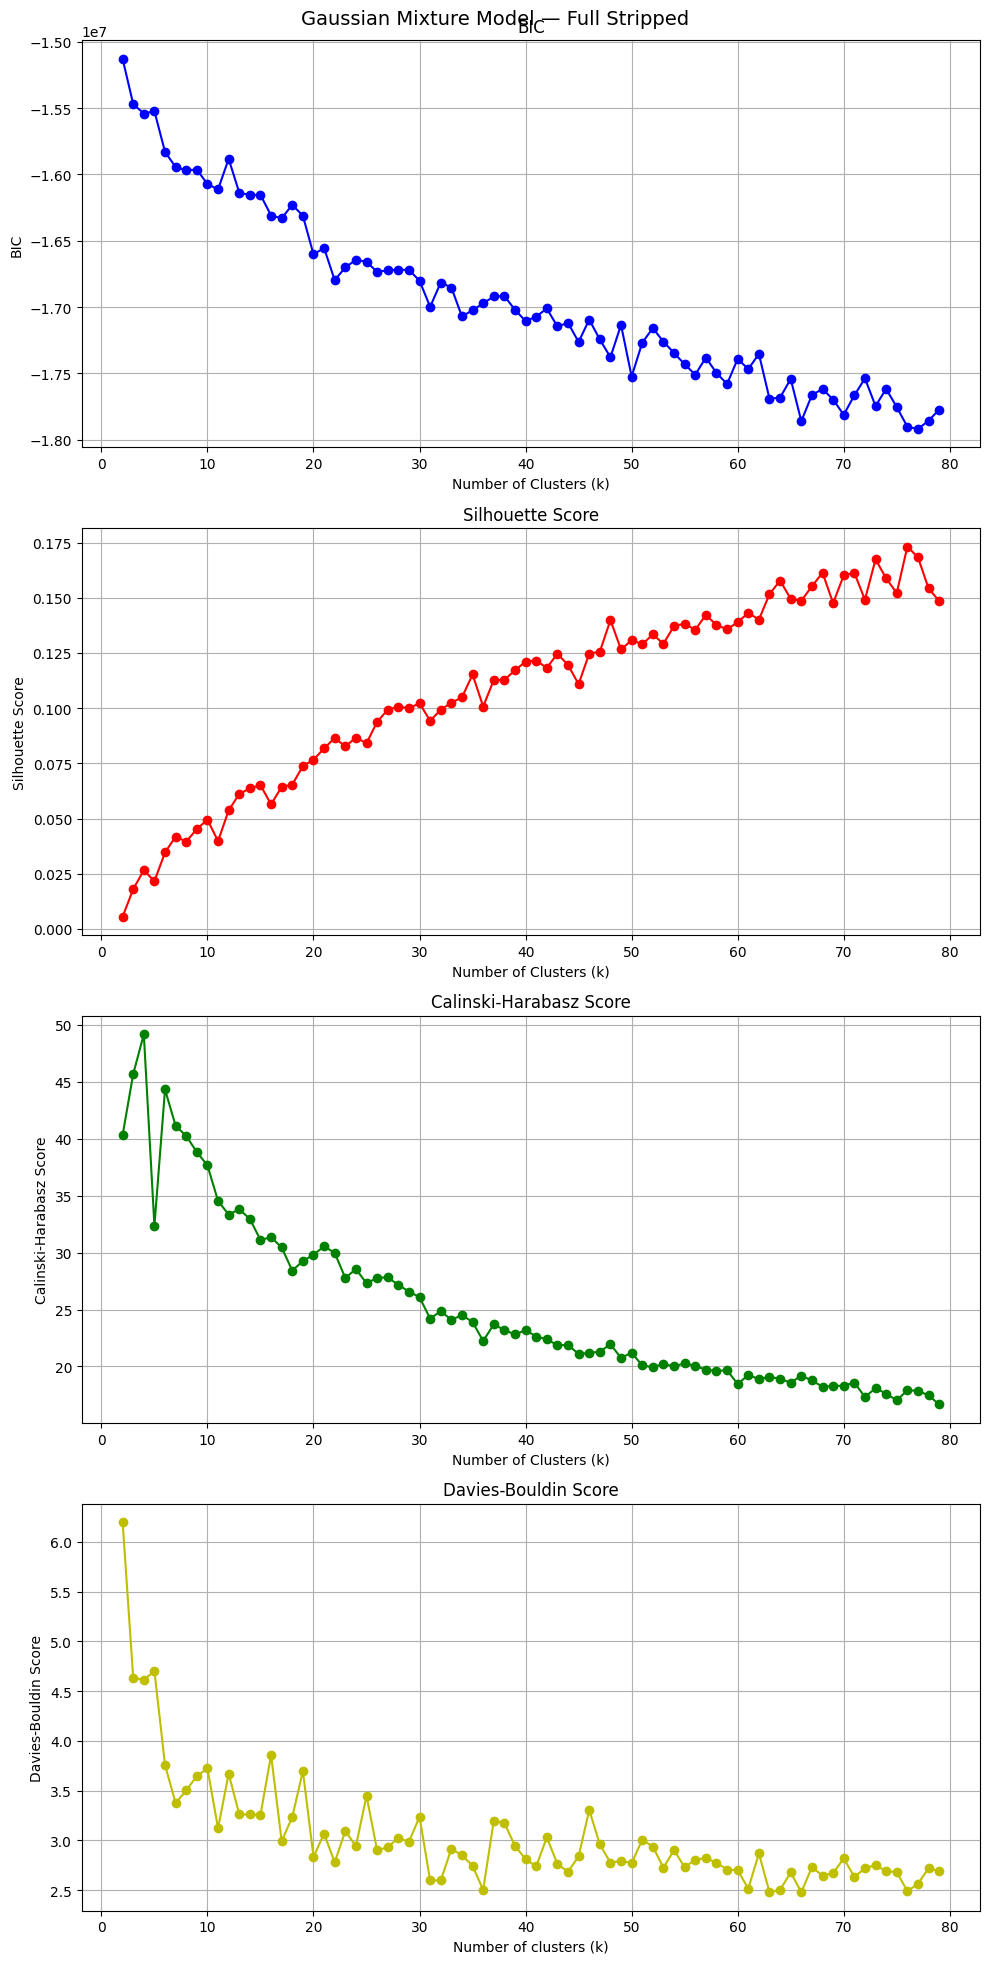

In [38]:
gmm_results = {}
k_range_gmm = range(2, 80)

for name, X_data in datasets_stripped.items():
    metrics = {"bic": [], "silhouette": [], "calinski": [], "davies": []}
    for k in k_range_gmm:
        gmm = GaussianMixture(n_components=k, covariance_type='spherical',
                              random_state=8, n_init=5, max_iter=200)
        gmm.fit(X_data)
        preds = gmm.predict(X_data)
        metrics["bic"].append(gmm.bic(X_data))
        metrics["silhouette"].append(
            silhouette_score(X_data, preds, sample_size=1000, random_state=8)
        )
        metrics["calinski"].append(
            calinski_harabasz_score(X_data, preds)
        )
        metrics["davies"].append(
            davies_bouldin_score(X_data, preds)
        )
    gmm_results[name] = metrics

    fig, axes = plt.subplots(4, 1, figsize=(10, 20))

    axes[0].plot(k_range_gmm, metrics["bic"], 'bo-')
    axes[0].set_title('BIC')
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('BIC')
    axes[0].grid(True)

    axes[1].plot(k_range_gmm, metrics["silhouette"], 'ro-')
    axes[1].set_title('Silhouette Score')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].grid(True)

    axes[2].plot(k_range_gmm, metrics["calinski"], 'go-')
    axes[2].set_title('Calinski-Harabasz Score')
    axes[2].set_xlabel('Number of Clusters (k)')
    axes[2].set_ylabel('Calinski-Harabasz Score')
    axes[2].grid(True)

    axes[3].plot(k_range_gmm, metrics["davies"], 'yo-')
    axes[3].set_title('Davies-Bouldin Score')
    axes[3].set_xlabel('Number of clusters (k)')
    axes[3].set_ylabel('Davies-Bouldin Score')
    axes[3].grid(True)


    plt.suptitle(f'Gaussian Mixture Model — {name}', fontsize=14)
    plt.tight_layout()
    plt.show()

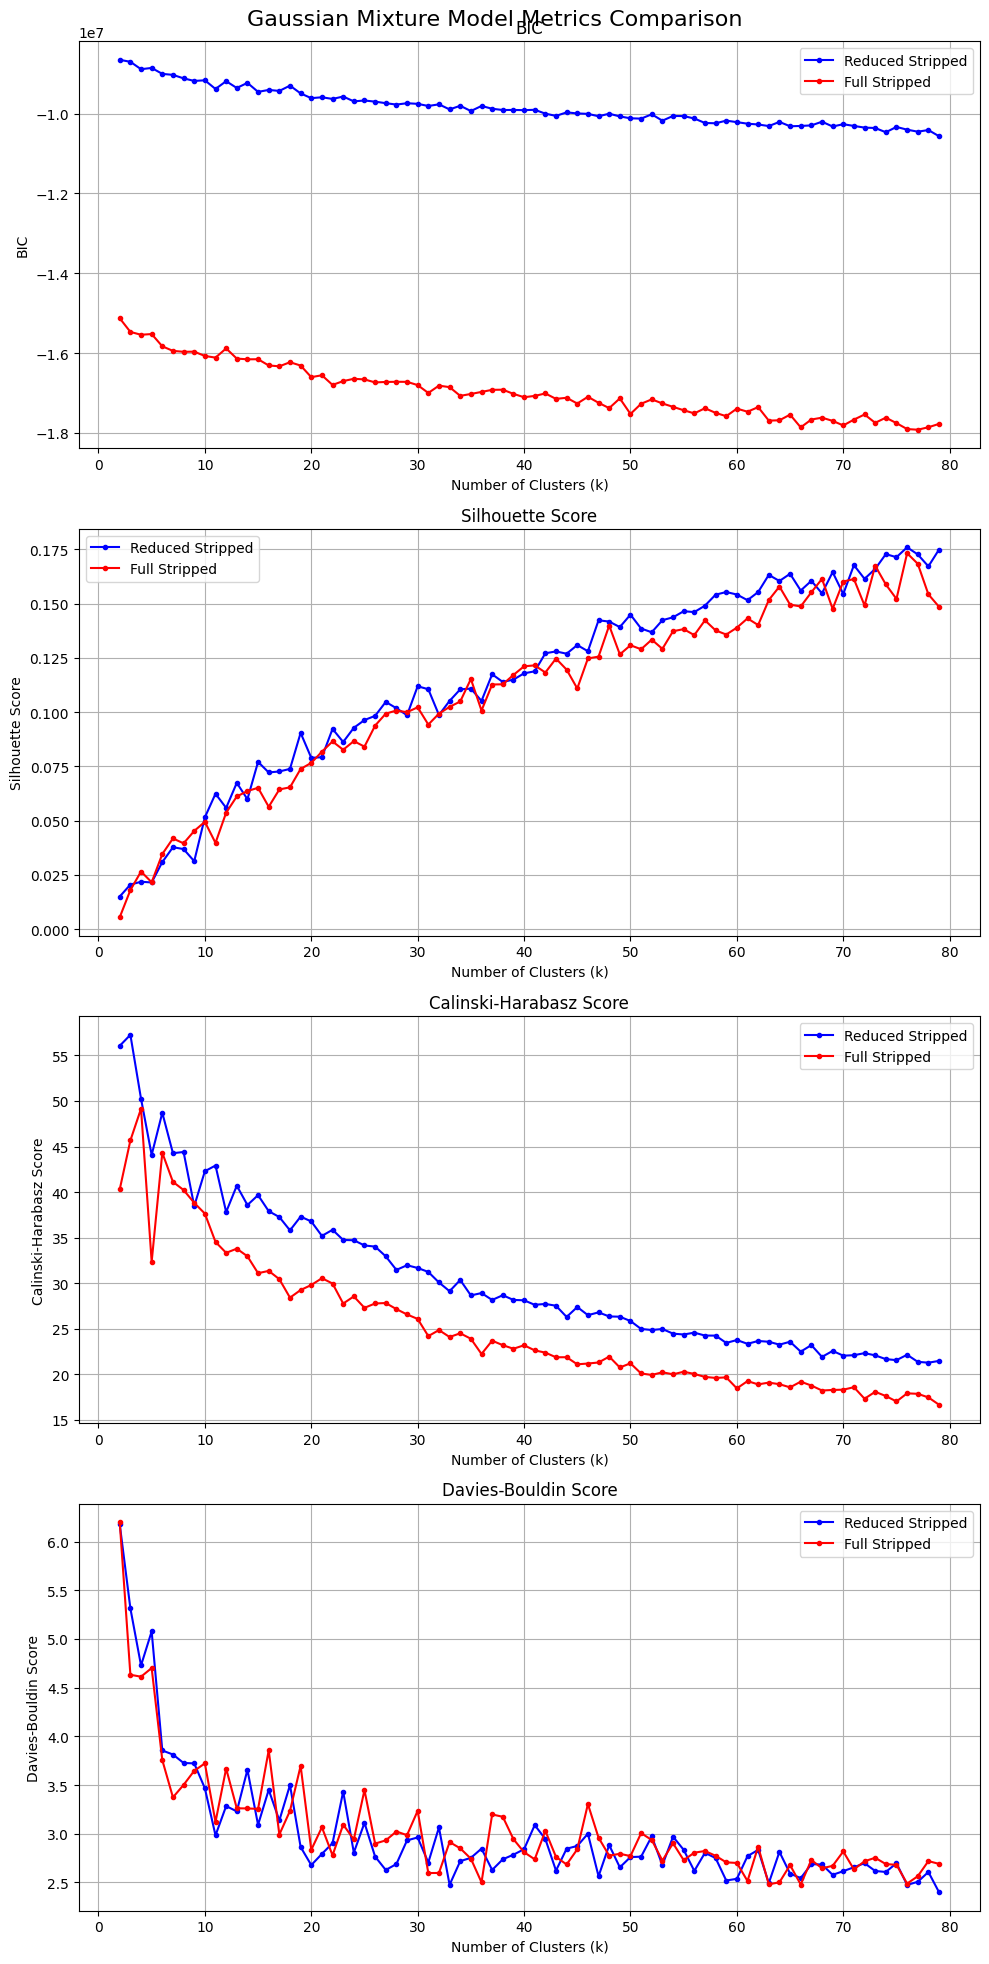

In [39]:
fig, axes = plt.subplots(4, 1, figsize=(10, 20))

metrics_to_plot = ['bic', 'silhouette', 'calinski', 'davies']
titles = ['BIC', 'Silhouette Score', 'Calinski-Harabasz Score', 'Davies-Bouldin Score']
colors = {'Reduced Stripped': 'blue', 'Full Stripped': 'red'}

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    for dataset_name, metrics in gmm_results.items():
        ax.plot(k_range_gmm, metrics[metric], marker='o', markersize=3,
                label=dataset_name, color=colors[dataset_name])
    ax.set_title(title)
    ax.set_xlabel('Number of Clusters (k)')
    ax.set_ylabel(title)
    ax.grid(True)
    ax.legend()

plt.suptitle('Gaussian Mixture Model Metrics Comparison', fontsize=16)
plt.tight_layout()
plt.show()

### Provera rezultata koristeci druge tipove kovarijacije

In [40]:
cov_types = ['full', 'tied', 'diag', 'spherical']
k = 40

for dataset_name, X_data in datasets_stripped.items():
    results = []
    for cov in cov_types:
        gmm = GaussianMixture(n_components=k, covariance_type=cov,
                              random_state=8, n_init=5, max_iter=300)
        gmm.fit(X_data)
        preds = gmm.predict(X_data)

        bic = gmm.bic(X_data)
        sil = silhouette_score(X_data, preds, sample_size=1000, random_state=8)
        cal = calinski_harabasz_score(X_data, preds)
        dav = davies_bouldin_score(X_data, preds)

        results.append({
            'Covariance': cov,
            'BIC': f"{bic:.1f}",
            'Silhouette': f"{sil:.4f}",
            'Calinski‑Harabasz': f"{cal:.1f}",
            'Davies-Bouldin': f"{dav:.1f}"
        })

    df_compare = pd.DataFrame(results).set_index('Covariance')
    display(df_compare.style
            .set_caption(f"GMM Metrics at k={k} — {dataset_name}")
            .set_properties(**{'text-align': 'center'})
            .background_gradient(subset=['BIC'], cmap='RdYlGn_r')
            .background_gradient(subset=['Silhouette'], cmap='RdYlGn')
            .background_gradient(subset=['Calinski‑Harabasz'], cmap='RdYlGn')
            .background_gradient(subset=['Davies-Bouldin'], cmap='RdYlGn')
           )

,BIC,Silhouette,Calinski‑Harabasz,Davies-Bouldin
Covariance,,,,
full,56686946.6,0.1185,26.9,3.3
tied,-7629725.7,0.1278,28.0,2.9
diag,-10793364.0,0.0732,19.6,4.2
spherical,-9916390.5,0.1179,28.1,2.8


,BIC,Silhouette,Calinski‑Harabasz,Davies-Bouldin
Covariance,,,,
full,158798148.7,0.1103,21.9,3.8
tied,-11553039.2,0.1251,23.6,3.2
diag,-19202896.0,0.0766,17.1,5.1
spherical,-17104969.8,0.1211,23.2,2.8


Mean confidence (max probability): 0.998


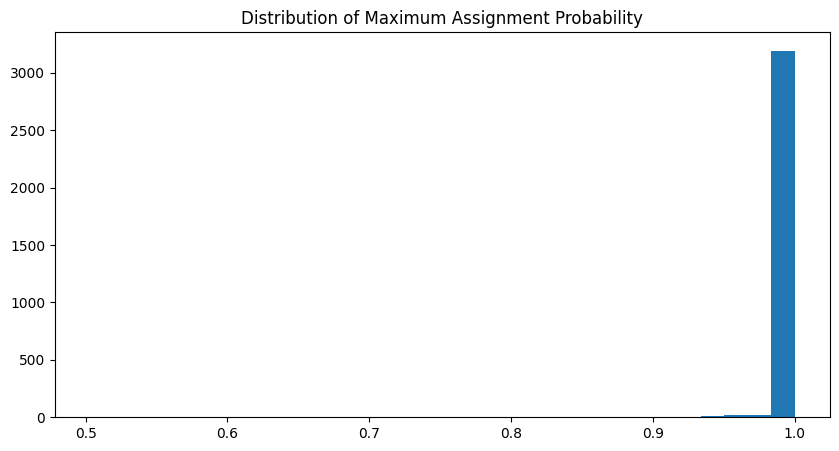

In [41]:
gmm_reduced_final = GaussianMixture(n_components=40, covariance_type='spherical',
                            random_state=8, n_init=10, max_iter=500)
gmm_reduced_final.fit(X_lsa_reduced_stripped)
cluster_labels_gmm_reduced = gmm_reduced_final.predict(X_lsa_reduced_stripped)
probabilities = gmm_reduced_final.predict_proba(X_lsa_reduced_stripped)
max_proba = probabilities.max(axis=1)
print(f"Mean confidence (max probability): {max_proba.mean():.3f}")

clustering_results.append({
    'Algorithm': 'Gaussian mixture model',
    'Dataset': 'reduced Stripped',
    'Number of Clusters': 40,
    'Silhouette': silhouette_score(X_lsa_reduced_stripped, cluster_labels_gmm_reduced, sample_size=1000, random_state=8),
    'Calinski‑Harabasz': calinski_harabasz_score(X_lsa_reduced_stripped, cluster_labels_gmm_reduced),
    'Davies-Bouldin': davies_bouldin_score(X_lsa_reduced_stripped, cluster_labels_gmm_reduced)
})

plt.figure(figsize=(10, 5))
plt.hist(max_proba, bins=30)
plt.title('Distribution of Maximum Assignment Probability')
plt.show()

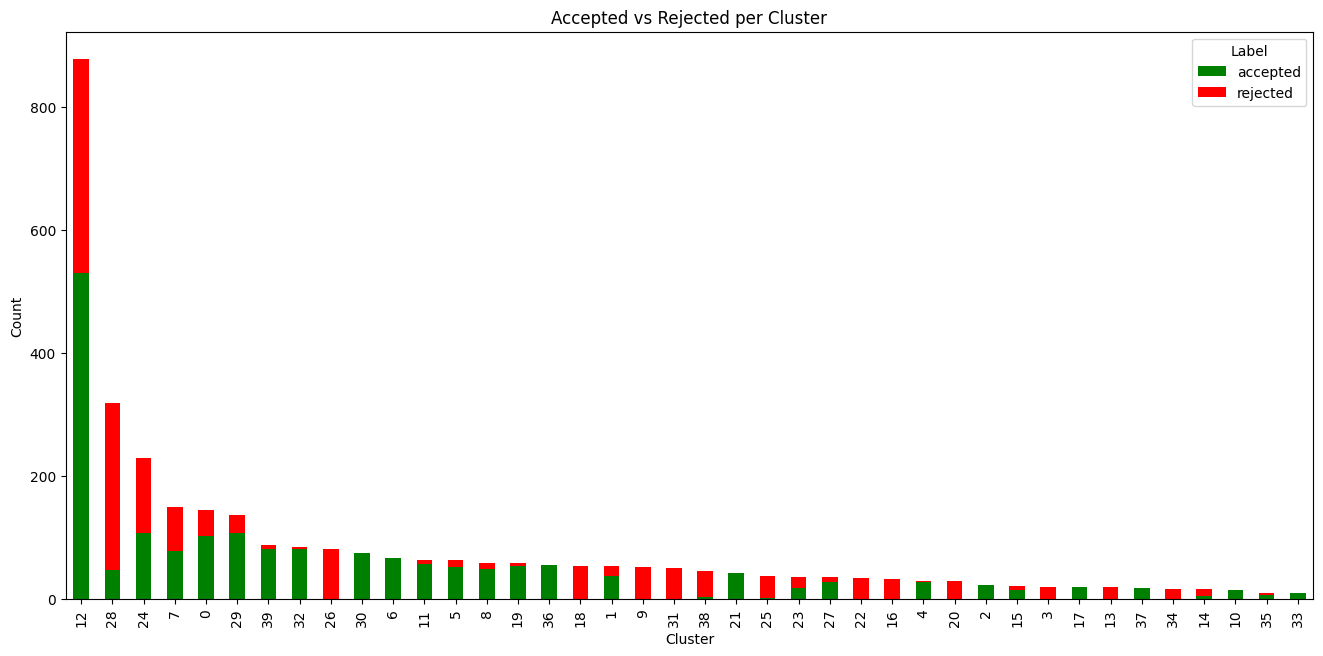

true_label,accepted,rejected,total,pct_accepted,top_terms
cluster,,,,,
2,22,0,22,100.000000,"smoothie, loser, biggest, smoothy, nbc, tuesday, frozen, idea, cool, fruit"
6,66,0,66,100.000000,"law, veterinary, justanswer, avatar, jpg, veterinarian, upload, appliance, positive, immigration"
17,19,0,19,100.000000,"hobby, poultry, livestock, alpaca, coop, farm, post, hydraulic, backyard, brooder"
37,18,0,18,100.000000,"cage, supply, pet, ferret, litter, clearance, bird, rabbit, low, habitat"
36,56,0,56,100.000000,"hunt, deer, game, hunter, goose, call, creek, elk, predator, trophy"
21,42,0,42,100.000000,"platinum, athletic, performance, reproduction, pak, hoof, equine, density, allergy, metabolic"
10,15,0,15,100.000000,"kitten, cat, identification, neuter, rescue, club, tag, behavior, adoption, checklist"
30,74,1,75,98.700000,"livestock, raise, subscription, acreage, machinery, poultry, renew, radio, classifi, breed"
32,81,3,84,96.400000,"dog, pet, cat, food, groome, supply, treat, care, flea, supplement"


In [42]:
show_cluster_composition(cluster_labels_gmm_reduced, X_tfidf_reduced_stripped, feature_names_reduced_stripped, 40)

Mean confidence (max probability): 0.999


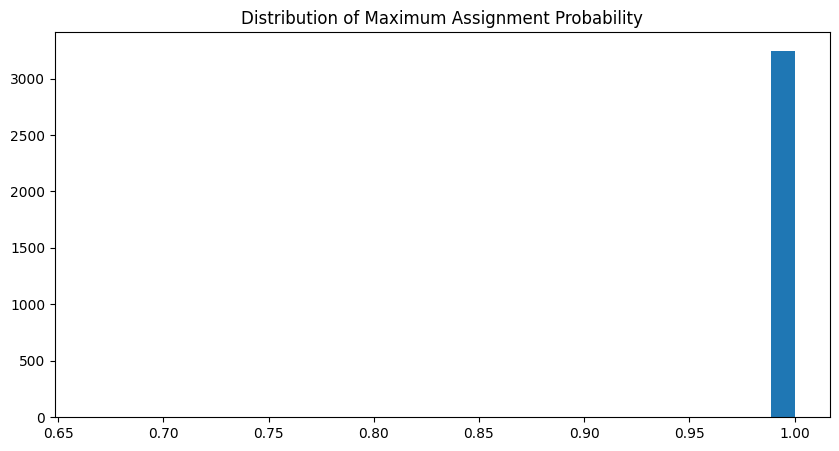

In [43]:
gmm_full_final = GaussianMixture(n_components=40, covariance_type='spherical',
                            random_state=8, n_init=10, max_iter=500)
gmm_full_final.fit(X_lsa_full_stripped)
cluster_labels_gmm_full = gmm_full_final.predict(X_lsa_full_stripped)
probabilities = gmm_full_final.predict_proba(X_lsa_full_stripped)
max_proba = probabilities.max(axis=1)
print(f"Mean confidence (max probability): {max_proba.mean():.3f}")

clustering_results.append({
    'Algorithm': 'Gaussian mixture model',
    'Dataset': 'full Stripped',
    'Number of Clusters': 40,
    'Silhouette': silhouette_score(X_lsa_full_stripped, cluster_labels_gmm_full, sample_size=1000, random_state=8),
    'Calinski‑Harabasz': calinski_harabasz_score(X_lsa_full_stripped, cluster_labels_gmm_full),
    'Davies-Bouldin': davies_bouldin_score(X_lsa_full_stripped, cluster_labels_gmm_full)
})

plt.figure(figsize=(10, 5))
plt.hist(max_proba, bins=30)
plt.title('Distribution of Maximum Assignment Probability')
plt.show()

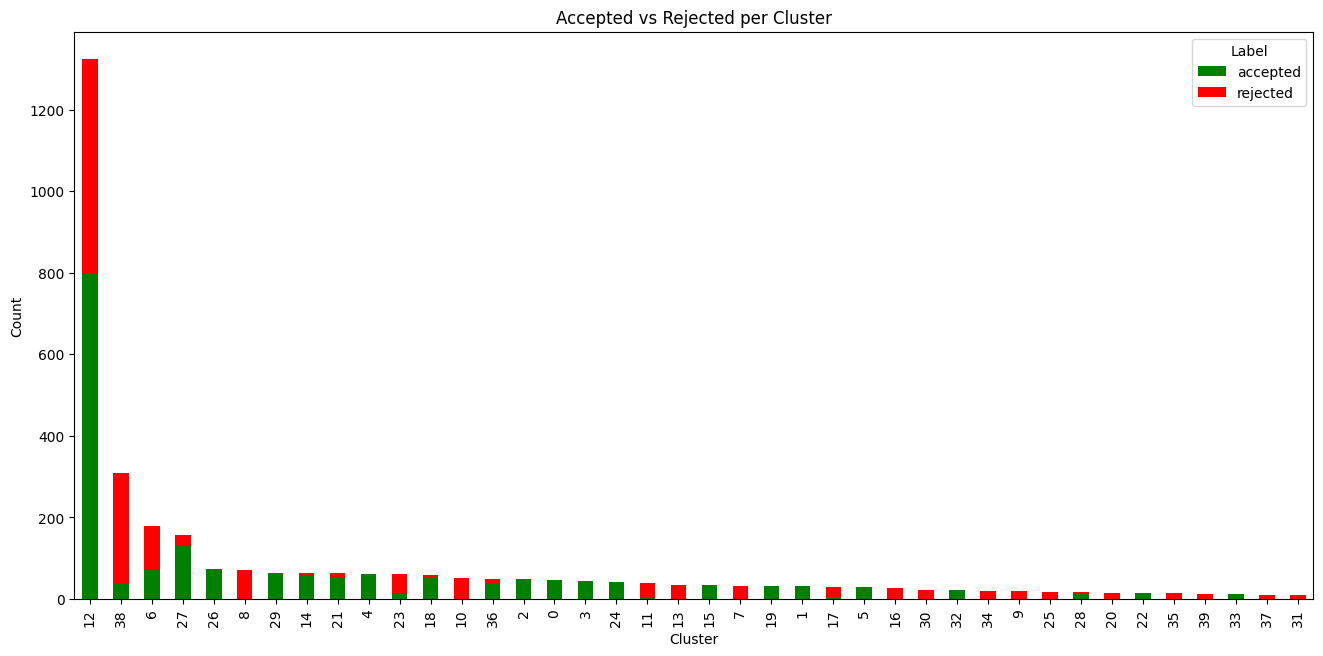

true_label,accepted,rejected,total,pct_accepted,top_terms
cluster,,,,,
1,31,0,31,100.000000,"poultry, geese, chicken, coop, backyard, acreage, raise, duck, country, bantam"
4,62,0,62,100.000000,"law, veterinary, justanswer, avatar, jpg, veterinarian, appliance, upload, positive, jodi"
33,11,0,11,100.000000,"livestock, equipment, quickly, business, supply, found, handle, cattle, swine, wholesale"
32,22,0,22,100.000000,"yoplait, smoothie, loser, biggest, smoothy, nbc, tuesday, frozen, idea, cool"
24,42,0,42,100.000000,"platinum, athletic, performance, reproduction, pak, hoof, equine, density, allergy, metabolic"
22,15,0,15,100.000000,"cass, hunt, deer, goose, game, nomad, predator, creek, fox, electronic"
19,32,0,32,100.000000,"supply, pet, rabbit, trust, drsfostersmith, guinea, foster, cage, pig, name"
15,34,0,34,100.000000,"kitten, hobby, thread, nor, post, breed, subscriber, farm, litterbox, cat"
0,46,1,47,97.900000,"hunt, deer, ranch, whitetail, trophy, outfitter, lodge, hunter, elk, game"


In [44]:
show_cluster_composition(cluster_labels_gmm_full, X_tfidf_full_stripped, feature_names_full_stripped, 40)

In [49]:
clustering_results_df = pd.DataFrame(clustering_results)
clustering_results_df.style.background_gradient(subset=['Silhouette', 'Calinski‑Harabasz'], cmap='RdYlGn').background_gradient(subset=['Davies-Bouldin'], cmap='RdYlGn_r')

,Algorithm,Dataset,Number of Clusters,Silhouette,Calinski‑Harabasz,Davies-Bouldin
0,KMeans,Reduced Stripped,38.000000,0.129958,29.947824,2.903968
1,KMeans,Full Stripped,38.000000,0.116605,24.282312,3.226623
2,Bisecting KMeans,Reduced Stripped,38.000000,0.097970,23.621998,4.024145
3,Bisecting KMeans,Full Stripped,38.000000,0.074918,16.412614,4.862145
4,Agglomerative clustering,Reduced Stripped,12.000000,0.054182,43.665119,3.025491
5,Agglomerative clustering,Full Stripped,13.000000,0.065537,38.235047,2.134568
6,HDBSCAN,Reduced Stripped,nan,nan,nan,nan
7,HDBSCAN,Full Stripped,nan,nan,nan,nan
8,Gaussian mixture model,reduced Stripped,40.000000,0.119839,27.878658,2.892715
9,Gaussian mixture model,full Stripped,40.000000,0.111192,22.854085,2.846424
